<a href="https://colab.research.google.com/github/romidj/PFE-CpG-islands/blob/main/Epigenetics_Data_Characterisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Phase 1: Data Characterization
Adapted for environment:
  - epi_signals.h5[eid][mark] → (29378, 128) float16
  - mark_mask_matrix.npy      → (10, 9) uint8
  - window_index.parquet      → 29378 rows
  - epi_profiles.parquet      → 293780 rows (29378 × 10)
  - window_embeddings.npy     → (29378, 512) float32
"""

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path('/content/drive/MyDrive/PFE/data')
SEQ_DIR = BASE / 'processed'
EPI_DIR = BASE / 'epigenetics' / 'processed'
FIG_DIR = EPI_DIR / 'figures' / 'phase1'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MARKS = ['H3K4me3','H3K4me1','H3K36me3','H3K27me3','H3K9me3',
         'H3K27ac','H3K9ac','DNase','WGBS']
CELLS = ['E003','E017','E050','E067','E062',
         'E045','E065','E071','E104','E116']
CELL_NAMES = {
    'E003':'H1_ESC', 'E017':'IMR90', 'E050':'Brain_AG',
    'E067':'Brain_CX','E062':'Monocytes','E045':'HSC',
    'E065':'Aorta','E071':'Brain_HC','E104':'Heart_RA',
    'E116':'GM12878',
}

N_WINDOWS = 29378
N_MARKS   = 9
N_CELLS   = 10
N_BINS    = 128

# Step 0 — Pre-Flight HDF5 Alignment Check (MANDATORY FIRST)
Before running any analysis, verify that your data is properly aligned.



In [ ]:
import h5py
import pandas as pd
from pathlib import Path

print("=" * 60)
print("PRE-FLIGHT CHECK: HDF5 Alignment Verification")
print("=" * 60)

# Check 1: HDF5 has correct dimensions
try:
    # Use the correct path for epi_signals.h5
    with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
        n_hdf5 = f['E003']['H3K4me3'].shape[0]
        print(f"✓ HDF5 shape[0]: {n_hdf5}")
        assert n_hdf5 == 29378, f"ERROR: Expected 29,378 windows, got {n_hdf5}"
except Exception as e:
    print(f"✗ HDF5 load failed: {e}")
    raise

# Check 2: Window index matches
try:
    n_idx = len(pd.read_parquet(SEQ_DIR / 'window_index.parquet'))
    print(f"✓ Window index length: {n_idx}")
    assert n_idx == 29378, f"ERROR: Expected 29,378 windows, got {n_idx}"
except Exception as e:
    print(f"✗ Window index load failed: {e}")
    raise

# Check 3: Alignment assertion
assert n_hdf5 == n_idx == 29378, f"Alignment error: HDF5={n_hdf5}, index={n_idx}"

print("\n" + "=" * 60)
print("✅ ALL PRE-FLIGHT CHECKS PASSED")
print("=" * 60)
print("\nSafe to proceed with Phase 1 analysis.")

PRE-FLIGHT CHECK: HDF5 Alignment Verification
✓ HDF5 shape[0]: 29378
✓ Window index length: 29378

✅ ALL PRE-FLIGHT CHECKS PASSED

Safe to proceed with Phase 1 analysis.


In [ ]:
import h5py
# Import Path if not already imported in a previous cell and ensure EPI_DIR is defined
# (Assuming EPI_DIR is already defined and available from previous executed cells)
# from pathlib import Path
# BASE = Path('/content/drive/MyDrive/PFE/data')
# EPI_DIR = BASE / 'epigenetics' / 'processed'

with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
    signal = f['E003']['H3K4me3'][:]  # (29378, 128)

# Mini test -  Move it to step C , once it's done

In [ ]:
import numpy as np
# Ensure EPI_DIR is accessible. It's defined in cell 6IYgsx9F1UpG.
mark_mask = np.load(EPI_DIR / 'mark_mask_matrix.npy')  # (10, 9)
print(f"Coverage: {(mark_mask.sum() / mark_mask.size) * 100:.1f}%")

Coverage: 83.3%


Can the 512-dimensional sequence embedding predict the average H3K4me3 signal of E003?

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np, h5py

seq = np.load(SEQ_DIR / 'window_embeddings.npy')

with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
    signal = np.nanmean(f['E003']['H3K4me3'][:], axis=1)

valid = ~np.isnan(signal)

X = seq[valid]
y = signal[valid]

# sample only 5000 windows
rng = np.random.default_rng(42)
idx = rng.choice(len(X), 5000, replace=False)

X = X[idx]
y = y[idx]

rf = RandomForestRegressor(
    n_estimators=20,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

r2 = cross_val_score(
    rf,
    X,
    y,
    cv=3,
    scoring='r2',
    n_jobs=-1
).mean()

print(f"R² = {r2:.3f}")

R² = -0.107


A Random Forest regressor was trained to predict the mean H3K4me3 signal of the E003 epigenome from NT-v2 sequence embeddings. Using 5,000 randomly sampled windows and 3-fold cross-validation, the model achieved an R² score of −0.107, indicating that sequence embeddings alone cannot reliably reconstruct the epigenetic signal. This preliminary test suggests that sequence and epigenetic modalities contain complementary information, supporting the rationale for multimodal fusion. The reduced experiment serves as a fast validation of the analysis pipeline before scaling to all marks and epigenomes.

# Task 1A: Signal Profiling
**Goal**
Understand the raw epigenetic signal landscape: which marks are strong/weak, which cells have distinct profiles, what's the scale of variation.
This will help in deciding the epigetics architecture ***( weither the encoder is supposed to preserve spatial information? do epigenetics reaally preserve cell identity? marks identilty ? )***

## Step 1A.1: Per-mark signal characterisation - for Encoder Design
Why: Determine whether epigenetic profiles exhibit sparsity, heavy-tailed distributions, and cell-type-specific behaviour that should influence the encoder architecture.

In [ ]:
import numpy as np
import pandas as pd
import h5py
from scipy import stats

H5_PATH = EPI_DIR / 'epi_signals.h5'


rows = []

with h5py.File(H5_PATH, 'r') as f:

    for cell in CELLS:

        print(f'Processing {cell}')

        for mark in MARKS:

            if mark not in f[cell]:
                continue

            # ← FIX HERE
            signal = f[cell][mark][:].astype(np.float32) # ndirouh 32 because using float16 makes the std = inf and other metrics= NAN

            signal_flat = signal.reshape(-1)
            signal_flat = signal_flat[~np.isnan(signal_flat)]

            rows.append({
                'cell_type' : cell,
                'mark'      : mark,
                'mean'      : np.mean(signal_flat),
                'std'       : np.std(signal_flat),
                'median'    : np.median(signal_flat),
                'q25'       : np.percentile(signal_flat, 25),
                'q75'       : np.percentile(signal_flat, 75),
                'skewness'  : stats.skew(signal_flat),
                'kurtosis'  : stats.kurtosis(signal_flat),
                'sparsity'  : np.mean(signal_flat == 0),
                'n_nonzero' : np.sum(signal_flat > 0)
            })
rows[-1]['all_zero'] = bool(np.all(signal_flat == 0))
stats_df = pd.DataFrame(rows)


stats_df.to_csv(
    FIG_DIR / '1a_mark_statistics_by_cell.csv',
    index=False
)

display(stats_df)

Processing E003
Processing E017
Processing E050
Processing E067
Processing E062
Processing E045
Processing E065
Processing E071
Processing E104
Processing E116


,cell_type,mark,mean,std,median,q25,q75,skewness,kurtosis,sparsity,n_nonzero,all_zero
0,E003,H3K4me3,1.776826,7.926988,0.111023,0.065063,0.317139,5.429623,28.757952,0.019095,3688578,NaN
1,E003,H3K4me1,0.619601,1.332787,0.209961,0.090637,0.551758,5.802604,51.738262,0.019135,3688428,NaN
2,E003,H3K36me3,0.672254,1.462317,0.223022,0.134888,0.525879,6.733699,74.148178,0.019079,3688638,NaN
3,E003,H3K27me3,1.089100,4.998739,0.213745,0.115479,0.490234,8.367451,73.528267,0.019075,3688656,NaN
4,E003,H3K9me3,0.464137,0.890820,0.175171,0.124695,0.513184,9.754001,185.034378,0.019075,3688654,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
70,E116,H3K27me3,0.326039,0.357035,0.239014,0.178467,0.262451,4.043630,29.073875,0.022521,3675696,NaN
71,E116,H3K9me3,0.350590,0.511141,0.249756,0.193237,0.280029,8.434855,133.535400,0.022468,3675894,NaN
72,E116,H3K27ac,1.070900,4.869912,0.204346,0.146851,0.240356,7.660277,64.150871,0.022546,3675604,NaN
73,E116,H3K9ac,1.054807,4.969117,0.199219,0.140625,0.226196,7.775523,64.866524,0.022491,3675809,NaN


In [ ]:
stats_df[stats_df['all_zero'] == True]

,cell_type,mark,mean,std,median,q25,q75,skewness,kurtosis,sparsity,n_nonzero,all_zero


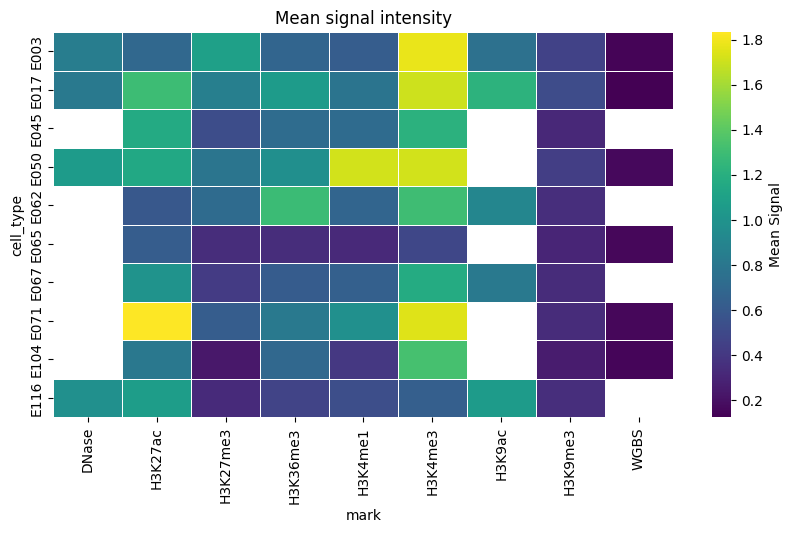

In [ ]:
stats_df['mean'] = stats_df['mean'].replace([np.inf, -np.inf], np.nan).astype(np.float64)
pivot = stats_df.pivot(
    index='cell_type',
    columns='mark',
    values='mean'
)

plt.figure(figsize=(10,5))
missing_mask = pivot.isna()

sns.heatmap(
    pivot,
    cmap='viridis',
    mask=missing_mask,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Signal'}
)
plt.title('Mean signal intensity')
plt.show()

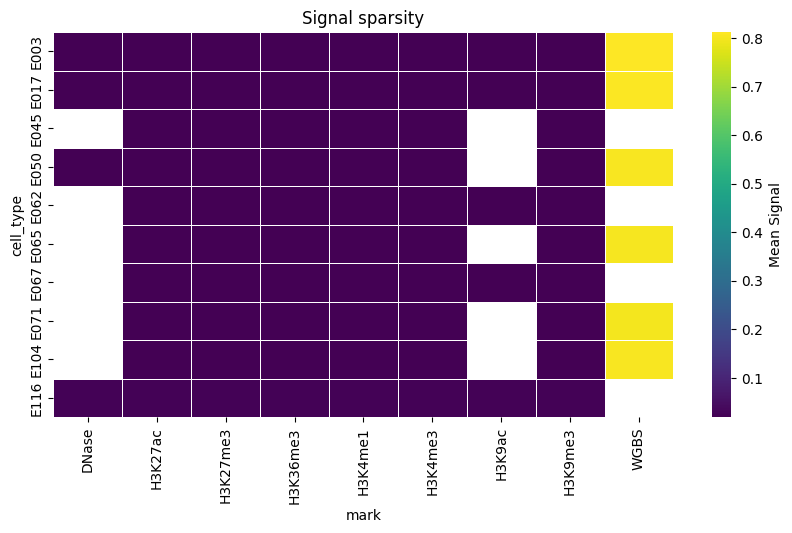

In [ ]:
pivot = stats_df.pivot(
    index='cell_type',
    columns='mark',
    values='sparsity'
)

plt.figure(figsize=(10,5))
missing_mask = pivot.isna()

sns.heatmap(
    pivot,
    cmap='viridis',
    mask=missing_mask,
    linewidths=0.5,
    cbar_kws={'label': 'Mean Signal'}
)
plt.title('Signal sparsity')
plt.show()

**Key Findings**
1. The epigenetic data are biologically coherent with CpG island biology. H3K4me3 shows the highest mean intensity across all cell types, consistent with the strong promoter enrichment characteristic of CpG islands. H3K27ac and H3K9ac follow with moderate-to-high signals, reflecting active regulatory activity. H3K9me3 remains comparatively weak, consistent with the known depletion of constitutive heterochromatin marks at CpG islands. WGBS displays the lowest overall intensity, reflecting the hypomethylated state typical of active CpG island promoters. These patterns confirm that the preprocessing pipeline preserves known CpG island biology and that any future modification producing substantially different profiles should be treated with suspicion.

2. Epigenetic signals are highly non-Gaussian across all marks. In nearly every mark, the mean substantially exceeds the median, skewness is strongly positive, and kurtosis is extreme. This indicates that signal distributions consist of a large mass of near-zero background values punctuated by a small number of strong, localised peaks — not smooth bell-shaped distributions. This rules out methods that implicitly assume Gaussian features, such as direct PCA-based compression or simple linear projections applied to raw bins, and motivates architectures capable of capturing localised peak structure, such as CNNs and attention mechanisms.

3. The epigenetic information is not only contained in how strong a signal is, but also in where it appears within the 2,048 bp region. Each window is divided into 128 small bins (16 bp each), and regulatory marks usually form peaks that occupy only some of these bins. The position, shape, and overlap between different marks carry important biological meaning. If we replace the entire 128-bin profile with a single average value, we lose this spatial pattern information. Therefore, the epigenetic encoder should be designed to recognize local patterns along the genomic region (for example using CNNs), rather than treating the data as a simple table of numbers.

4. The nine marks belong to distinct statistical and biological regimes. Active marks (H3K4me3, H3K27ac, H3K9ac) exhibit sharp, high-amplitude peaks and large variance. Broad repressive marks (H3K27me3, H3K9me3) show wider chromatin domains with different spatial organisation. DNA methylation (WGBS) is highly sparse - as seen in the signal sparcity heatmap- and arises from a fundamentally different biochemical process. These regimes are not interchangeable, and the architecture must preserve mark identity rather than averaging or pooling across channels early in the encoding process.

5. Missingness is systematic and biologically interpretable, not noise. The availability matrix reveals that certain epigenomes systematically lack specific assays — for example, DNase is absent in six of ten epigenomes and WGBS is absent in four. This reflects the experimental design of the Roadmap Epigenomics project, not data corruption. Imputing these values would introduce false biological signal. Missingness must remain explicit, and mask-aware architectures are scientifically justified rather than merely a robustness precaution.

6. Feature ablation becomes a scientific investigation. Because missingness is preserved explicitly, future experiments that simulate the absence of individual assays — for example, removing WGBS or DNase from the input — directly probe the practical contribution of each epigenetic modality to regulatory state prediction. This is not standard robustness testing; it is an empirical answer to the question of which assays carry the most information for functional state classification at CpG islands.

## **Step 1A.2 : Cell-type epigenetic landscape characterization**

**`Why`**: Determine whether different epigenomes exhibit distinct signal patterns, whether biologically related cell types cluster together, and whether the epigenetic encoder should explicitly model cell identity.

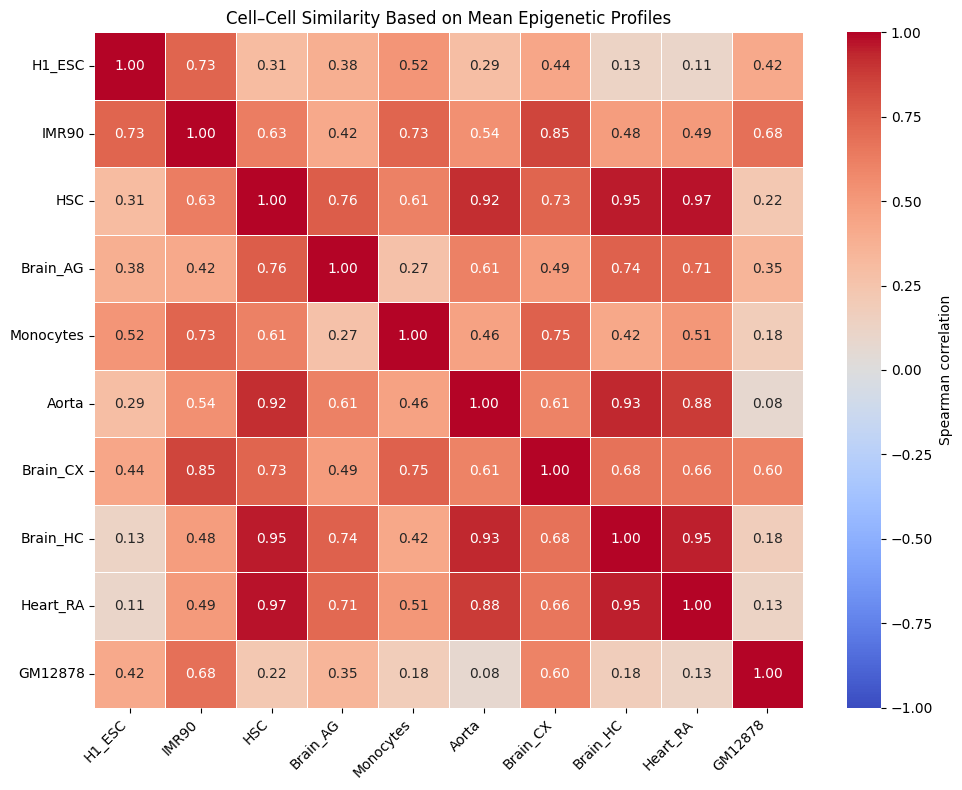

In [ ]:

# ---------------------------------------------------
# Cell-cell similarity based on mean mark profiles
# ---------------------------------------------------

# Fill NaN only for this exploratory comparison.
# Missing marks indicate unavailable assays rather
# than true absence of signal. This replacement is
# NOT used for modelling.
# Create Cell × Mark matrix from the previously computed statistics
cell_profiles = stats_df.pivot(
    index='cell_type',
    columns='mark',
    values='mean'
)

# Fill NaN only for this summary analysis
# Missing marks are treated as "not available" rather than true zero signal.
# This should NOT be used for downstream modelling.
cell_profiles_filled = cell_profiles.fillna(0)

# Compute cell-cell similarity
corr = cell_profiles_filled.T.corr(method='spearman')

# Sanity check
assert np.allclose(np.diag(corr.values), 1.0), \
    "Diagonal should be 1.0"

# Replace EIDs by descriptive names
corr.index = [CELL_NAMES[c] for c in corr.index]
corr.columns = [CELL_NAMES[c] for c in corr.columns]

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

plt.title('Cell–Cell Similarity Based on Mean Epigenetic Profiles')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The cell-cell similarity analysis revealed substantial heterogeneity in the global epigenetic landscapes across the ten epigenomes. While several biologically related cell types exhibited high correlations in their average signal intensities across the nine epigenetic marks, other cell types displayed markedly distinct profiles. These results indicate that the epigenetic modality captures meaningful cell-type-specific information and is therefore likely to contribute complementary information to the prediction task. However, this analysis is based solely on summary statistics derived from the average signal intensity of each mark and does not consider the spatial organization of signals within the 128-bin profiles. Consequently, while it confirms the existence of cell-type differences at a global level, it cannot characterize how these differences are distributed along the genomic window.


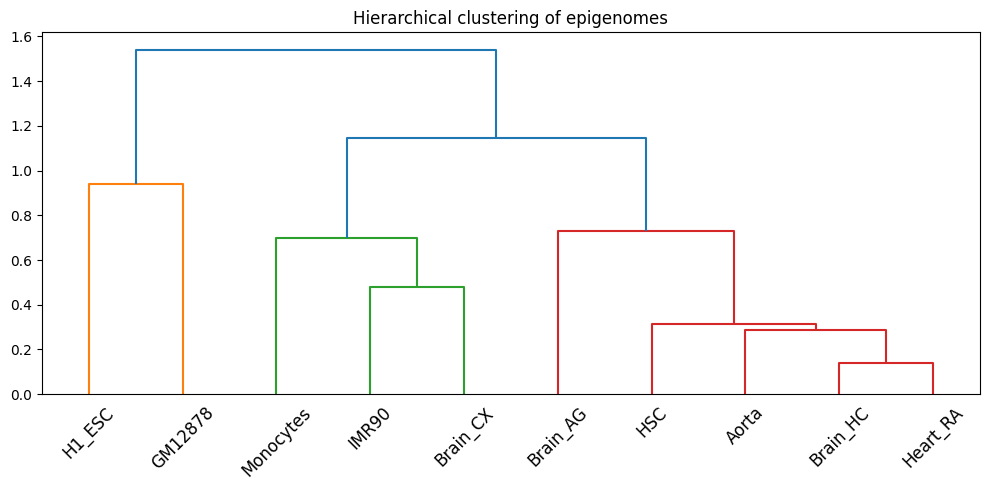

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
assert corr.values.min() >= -1 and corr.values.max() <= 1

Z = linkage(
    1 - corr,
    method='average'
)

plt.figure(figsize=(10,5))

dendrogram(
    Z,
    labels=corr.index.tolist(),
    leaf_rotation=45
)

plt.title('Hierarchical clustering of epigenomes')

plt.tight_layout()
plt.show()

Hierarchical clustering further supported the presence of structured relationships among epigenomes. Certain cell types formed coherent groups, suggesting shared epigenetic characteristics, whereas others occupied more isolated positions, reflecting specialized regulatory programs. Importantly, the observed clustering patterns arise from similarities in aggregate mark intensities rather than from the detailed spatial configuration of the epigenetic signals. Therefore, the dendrogram provides evidence that cell identity is encoded within the epigenetic data but does not capture whether distinct cell types exhibit differences in the location, shape, or co-occurrence of local signal peaks across the 2,048 bp windows.


**Synthesis**
The analyses performed in Phase 1A establish several important properties of the epigenetic dataset.
1. First, the availability analysis confirmed that the missing signals follow a biologically realistic pattern and can be explicitly modeled through the predefined masking strategy.
2.  Second, the per-mark statistics revealed substantial differences in signal intensity distributions, variability, and sparsity across the nine epigenetic marks, indicating that the marks encode distinct aspects of chromatin biology rather than redundant measurements of the same regulatory process.
3.  Third, the cell-level analyses demonstrated that the epigenomes possess meaningful cell-type-specific signatures, supporting the hypothesis that the epigenetic modality contributes information beyond the DNA sequence alone and motivating the use of cell-aware representations.


Importantly, all of these conclusions are derived from global summaries of the epigenetic signals and therefore do not account for the spatial organization of the original 128-bin profiles. Since regulatory information is frequently encoded through the position, width, and co-occurrence of local signal peaks across multiple marks, further investigations that preserve the sequential structure of the signals are necessary to fully characterize the epigenetic modality.

The observed cell-type specificity in mean signal patterns, combined with the systematic availability structure, provides a priori justification for ***an epigenetic encoder that operates on the full (9, 128) spatial profile rather than on pre-aggregated mark statistics.***


## 1A.3. Spatial Profile Analysis
Where is the signal located inside the 2048 bp region?
given our CpG-island-centered design. I think this is one of the strongest analyses in our whole Phase 1A because it's the first one that preserves the 128-bin spatial structure, whereas everything before (means, correlations, clustering) collapsed it.

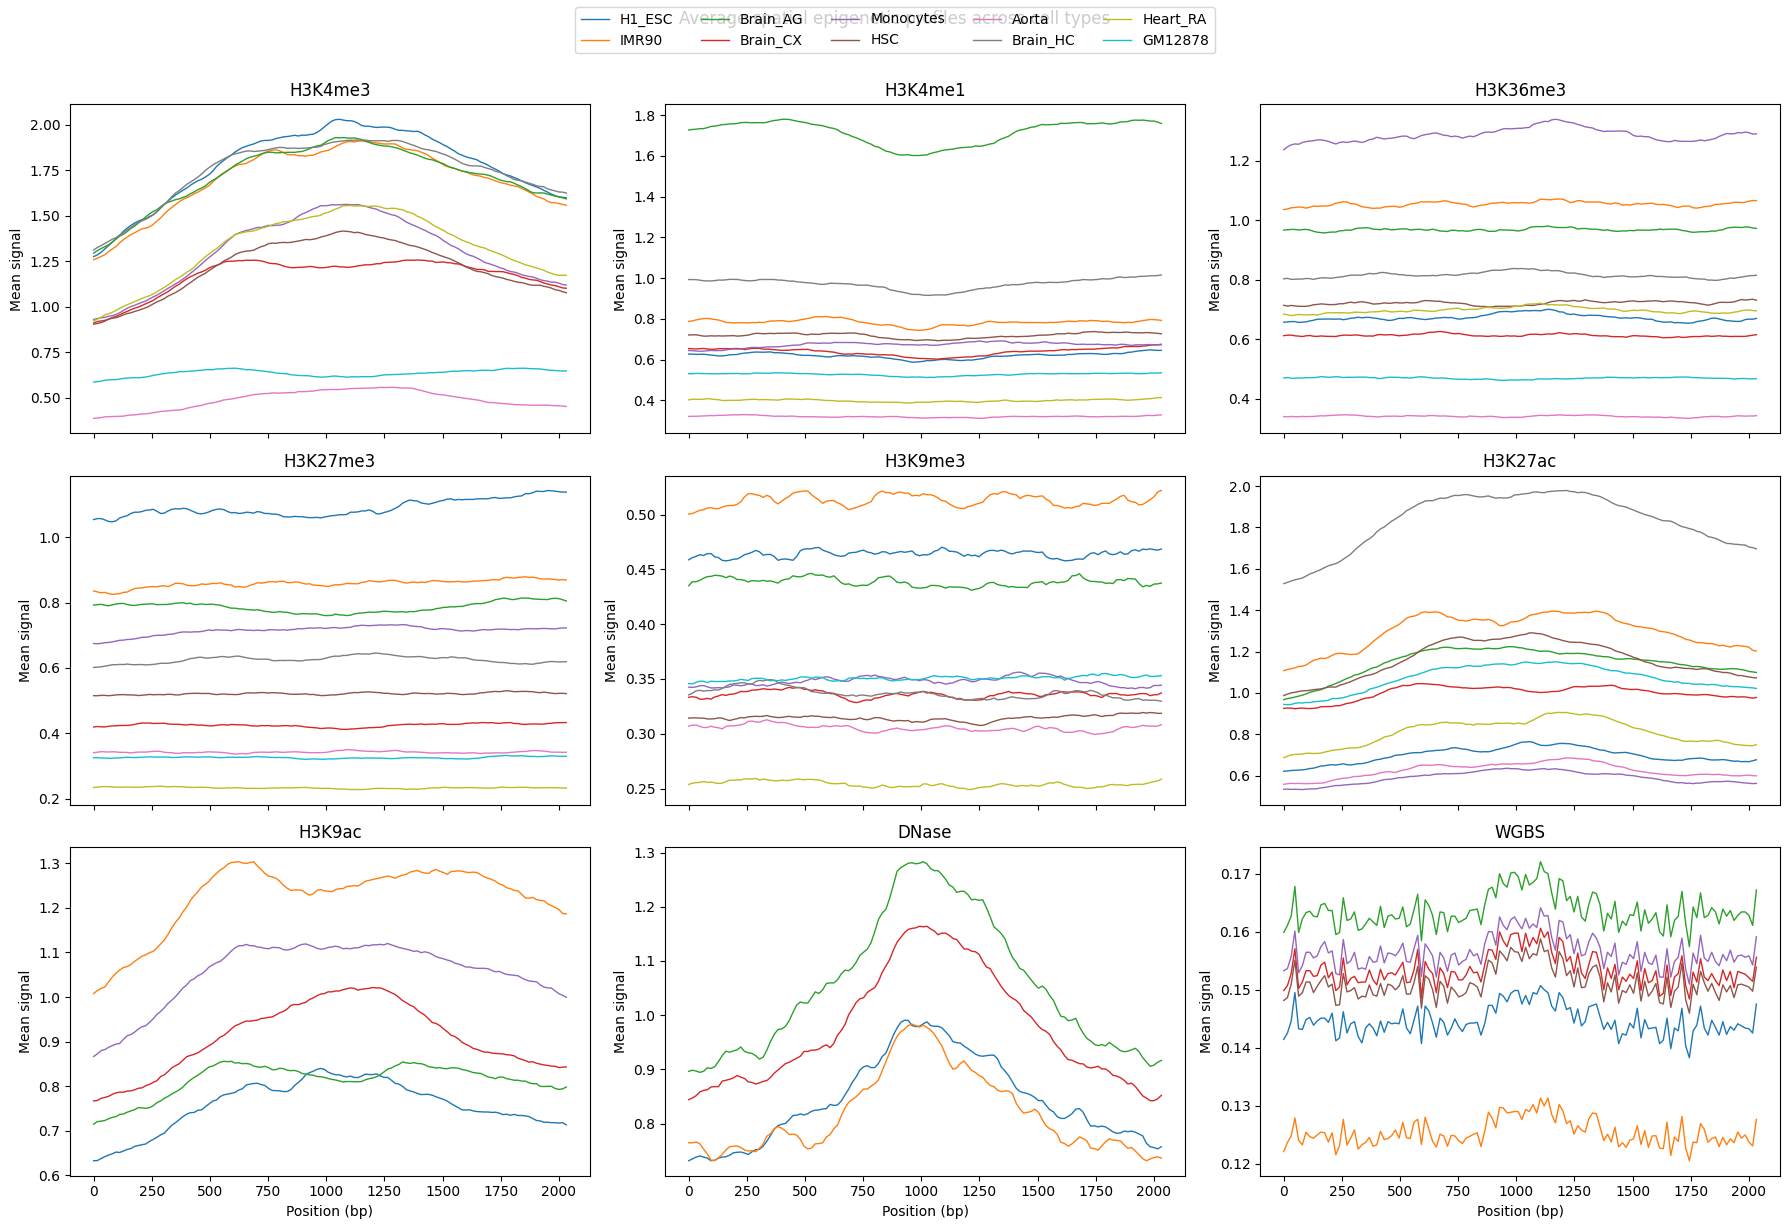

In [ ]:
fig, axes = plt.subplots(3, 3,
                         figsize=(18, 12),
                         sharex=True)

x = np.arange(128) * 16

with h5py.File(H5_PATH, 'r') as f:

    for mark, ax in zip(MARKS, axes.flatten()):

        for cell in CELLS:

            if mark not in f[cell]:
                continue

            profile = f[cell][mark][:].mean(axis=0)

            ax.plot(
                x,
                profile,
                label=CELL_NAMES[cell],
                linewidth=1
            )

        ax.set_title(mark)
        ax.set_ylabel('Mean signal')

axes[-1,0].set_xlabel('Position (bp)')
axes[-1,1].set_xlabel('Position (bp)')
axes[-1,2].set_xlabel('Position (bp)')

handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(handles,
           labels,
           loc='upper center',
           ncol=5)

plt.suptitle(
    'Average spatial epigenetic profiles across cell types',
    y=1.02
)

plt.tight_layout()

plt.show()


***Key Findings***


 The mean spatial profiles across all nine marks reveal three distinct regimes with direct implications for encoder design. Active chromatin marks (H3K4me3, H3K27ac, H3K9ac, DNase) exhibit clear peaks centred on the CpG island at approximately position 1,000–1,100 bp, with both peak shape and magnitude varying substantially across cell types. This confirms that spatial information is biologically meaningful for these channels and that the encoder must preserve the 128-bin structure rather than collapsing to a scalar summary. Broad chromatin marks (H3K4me1, H3K36me3, H3K27me3) display flat profiles with cell-type differences encoded entirely in signal magnitude rather than spatial organisation, consistent with their known kilobase-scale domains that cannot be resolved within a 2,048 bp window. Near-silent marks (H3K9me3, WGBS) show minimal signal and spatial variation, contributing primarily through presence or absence rather than through peak patterns.



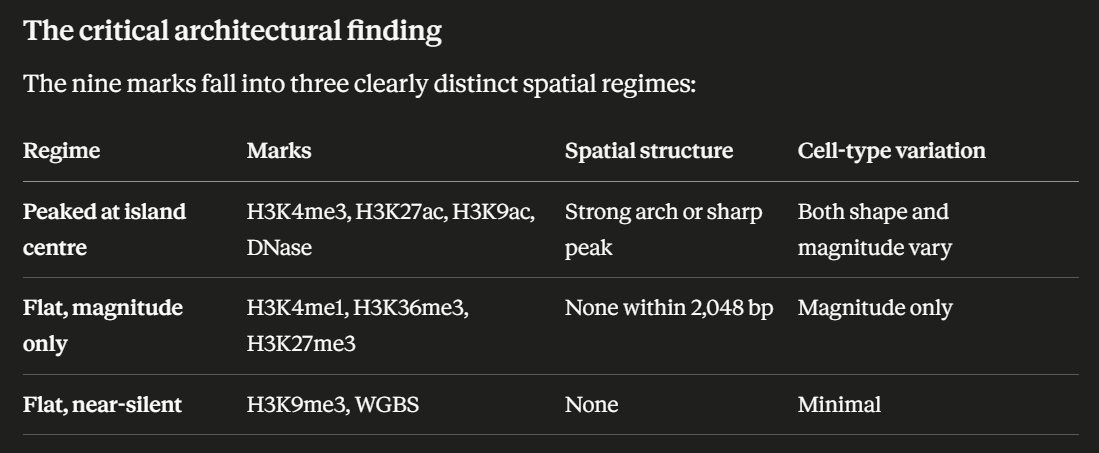


***Decisional synthesis***


*   The encoder must preserve the 128-bin spatial dimension rather than collapsing it to a scalar before encoding, because at least four marks (H3K4me3, H3K27ac, H3K9ac, DNase) carry peak-position information

* The encoder should be receptive-field aware ( receptive field aware means that an algorithm, system, or model understands the size and exact location of the input data that influences a specific processing unit.), the peaks span roughly 400–800 bp, which corresponds to 25–50 bins.
Convolutional kernels of size 7–15 (covering 112–240 bp) are appropriate for the first layer

* Channel identity must be preserved because the nine marks are in completely different statistical regimes and should not be averaged or pooled across channels before encoding

* The peaked marks are the primary carriers of spatial information and their peak position encodes which cell type is active at that locus ( typically where the cpG island is located inside the window) — the DNase panel makes this especially clear

* Marks H3K9me3 and WGBS contribute primarily through presence/absence rather than spatial structure, which further justifies the mask-aware architecture



## Step 1A.4: Mark Co-Activity Patterns


###Step 1A.4a: Mark Co-Activity Patterns across cells


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1A.4: Mark Co-Activity Patterns
# ─────────────────────────────────────────────────────────────────────────────
# Goal: Understand which epigenetic marks co-occur at the same CpG island
# windows, revealing biological co-regulation patterns (e.g. H3K4me3 +
# H3K27ac at active promoters, H3K27me3 + H3K9me3 at repressed loci).
#
# Binarisation thresholds — biologically grounded, not data-driven:
#
# Histone marks + DNase (MACS2 -log10 p-value tracks):
#   Threshold = 2.0  →  p < 0.01 (stringent peak-calling cutoff)
#   Reference: Zhang et al. (2008) MACS, Genome Biology 9:R137
#              Landt et al. (2012) ENCODE ChIP-seq guidelines, Genome Res 22:1813
#
# Broad repressive marks (H3K27me3, H3K9me3, H3K36me3):
#   Threshold = 1.5  →  p < 0.032 (relaxed cutoff for broad domains)
#   Reference: Hoffman et al. (2013) ChromHMM, Nature Methods 9:215
#              Ernst & Kellis (2012) ChromHMM, Nature Protocols 7:590
#
# WGBS (fractional methylation, range [0, 1]):
#   A bin is "active" (hypomethylated) if methylation < 0.30
#   Reference: Stadler et al. (2011) DNA-binding factors shape the mouse
#              methylome at distal regulatory regions, Nature 480:490
#              Ziller et al. (2013) Charting a dynamic DNA methylation
#              landscape of the human genome, Nature 500:477
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Per-mark binarisation thresholds ─────────────────────────────────────────
# A bin is considered "active" for that mark if signal > threshold.
# For WGBS the logic is inverted: active (hypomethylated) means signal < threshold.

MARK_THRESHOLDS = {
    # Sharp active marks — MACS2 -log10(p) > 2.0 (p < 0.01)
    'H3K4me3'  : ('gt', 2.0),   # gt = signal > threshold is active
    'H3K27ac'  : ('gt', 2.0),
    'H3K9ac'   : ('gt', 2.0),
    'DNase'    : ('gt', 2.0),
    'H3K4me1'  : ('gt', 2.0),   # enhancer mark, same pipeline
    # Broad repressive/transcribed marks — relaxed threshold for broad domains
    'H3K27me3' : ('gt', 1.5),
    'H3K9me3'  : ('gt', 1.5),
    'H3K36me3' : ('gt', 1.5),
    # WGBS — active = hypomethylated (fractional methylation < 0.30)
    'WGBS'     : ('lt', 0.30),  # lt = signal < threshold is active
}

# ── Build the 4D signal array (same construction as earlier cells) ────────────
# Shape: (N_WINDOWS, N_MARKS, N_CELLS, N_BINS)
# NaN where mark is unavailable for a given epigenome.

print("Building 4D signal array for co-activity analysis...")
data = np.full(
    (N_WINDOWS, N_MARKS, N_CELLS, N_BINS),
    np.nan,
    dtype=np.float32,
)

mark_mask = np.load(EPI_DIR / 'mark_mask_matrix.npy')  # (10, 9) uint8

with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
    for c_idx, eid in enumerate(CELLS):
        for m_idx, mark in enumerate(MARKS):
            if mark_mask[c_idx, m_idx] == 0:
                continue
            if mark not in f.get(eid, {}):
                continue
            data[:, m_idx, c_idx, :] = f[eid][mark][:].astype(np.float32)

print(f"  data shape : {data.shape}")
print(f"  NaN fraction (missing marks): {np.isnan(data).mean():.3f}")

Building 4D signal array for co-activity analysis...
  data shape : (29378, 9, 10, 128)
  NaN fraction (missing marks): 0.167


In [ ]:
# ── Binarise using per-mark biological thresholds ────────────────────────────
# Result shape: (N_WINDOWS, N_MARKS, N_CELLS, N_BINS), dtype uint8
# 1 = bin is in "active" state for that mark
# 0 = bin is below threshold OR mark is unavailable (NaN positions → 0)

data_binary = np.zeros(
    (N_WINDOWS, N_MARKS, N_CELLS, N_BINS),
    dtype=np.uint8,
)

for m_idx, mark in enumerate(MARKS):
    direction, threshold = MARK_THRESHOLDS[mark]
    mark_data = data[:, m_idx, :, :]   # (N_WINDOWS, N_CELLS, N_BINS)

    if direction == 'gt':
        active = mark_data > threshold
    else:   # 'lt' — WGBS: active = hypomethylated
        active = mark_data < threshold

    # NaN positions (missing mark) remain 0 — not active, not misleading
    active[np.isnan(mark_data)] = False
    data_binary[:, m_idx, :, :] = active.astype(np.uint8)

# Verification: check that thresholds produce reasonable active fractions
print("Active bin fractions per mark (sanity check):")
print(f"  Expected: ~10-30% for histone marks, ~30-60% for WGBS")
print()
for m_idx, mark in enumerate(MARKS):
    total_bins = data_binary[:, m_idx, :, :].size
    active_bins = data_binary[:, m_idx, :, :].sum()
    # Only count positions where mark is available
    avail_bins  = (~np.isnan(data[:, m_idx, :, :])).sum()
    if avail_bins == 0:
        print(f"  {mark:<12}: NO DATA")
        continue
    frac = active_bins / avail_bins
    direction, threshold = MARK_THRESHOLDS[mark]
    print(f"  {mark:<12}: {frac*100:5.1f}% active  "
          f"(threshold: signal {'>' if direction=='gt' else '<'} {threshold})")

Active bin fractions per mark (sanity check):
  Expected: ~10-30% for histone marks, ~30-60% for WGBS

  H3K4me3     :   5.4% active  (threshold: signal > 2.0)
  H3K4me1     :   7.3% active  (threshold: signal > 2.0)
  H3K36me3    :  10.3% active  (threshold: signal > 1.5)
  H3K27me3    :   7.1% active  (threshold: signal > 1.5)
  H3K9me3     :   3.9% active  (threshold: signal > 1.5)
  H3K27ac     :   6.4% active  (threshold: signal > 2.0)
  H3K9ac      :   6.0% active  (threshold: signal > 2.0)
  DNase       :   5.1% active  (threshold: signal > 2.0)
  WGBS        :  82.7% active  (threshold: signal < 0.3)


* The observed active fractions (3.9–10.3% for histone marks and DNase) are lower than generic genome-wide expectations but are consistent with the structure of the present dataset. Each sample corresponds to a 2,048 bp window centred on a CpG island, while the CpG island itself typically occupies only a subset of the window. Epigenetic enrichment is generally concentrated near the island centre and does not extend across the full genomic context. Consequently, only a limited fraction of the 128 bins per window exceed the biological activity thresholds, even for strongly enriched regions.

* This interpretation is supported by the spatial profile analysis of H3K4me3, which showed signal enrichment concentrated around the window centre rather than uniformly distributed across the entire window. Therefore, the relatively low active-bin fractions reflect the spatial localisation of regulatory signals within CpG-island-centred windows rather than overly stringent threshold selection.

* The WGBS track showed 82.7% of bins below the 0.30 methylation threshold, consistent with the well-established hypomethylated nature of CpG islands. This observation provides an independent biological validation of the window extraction and preprocessing pipeline.


In [ ]:
# ── Compute Jaccard co-activity matrix ───────────────────────────────────────
# For each mark pair (m1, m2):
#   A window is "co-active" if at least one bin is active for BOTH marks
#   in at least one cell where BOTH marks are available.
#
# Jaccard = |co-active windows| / |windows active in either mark|
#
# Only compute over windows where BOTH marks have data (mask intersection).
# This avoids inflating Jaccard by treating unavailable marks as inactive.

print("\nComputing Jaccard co-activity matrix...")

coactivity_matrix = np.zeros((N_MARKS, N_MARKS), dtype=np.float32)

for m1 in range(N_MARKS):
    for m2 in range(N_MARKS):

        # Find cells where BOTH marks are available
        cells_m1 = np.where(mark_mask[:, m1] == 1)[0]
        cells_m2 = np.where(mark_mask[:, m2] == 1)[0]
        joint_cells = np.intersect1d(cells_m1, cells_m2)

        if len(joint_cells) == 0:
            coactivity_matrix[m1, m2] = np.nan
            continue

        # For each window: is mark active in ANY bin across jointly available cells?
        # data_binary shape: (N_WINDOWS, N_MARKS, N_CELLS, N_BINS)
        m1_active = (
            data_binary[:, m1, :, :][:, joint_cells, :]
            .sum(axis=(1, 2)) > 0
        )  # (N_WINDOWS,) bool
        m2_active = (
            data_binary[:, m2, :, :][:, joint_cells, :]
            .sum(axis=(1, 2)) > 0
        )  # (N_WINDOWS,) bool

        both   = int((m1_active & m2_active).sum())
        either = int((m1_active | m2_active).sum())

        coactivity_matrix[m1, m2] = both / either if either > 0 else 0.0

coactivity_df = pd.DataFrame(
    coactivity_matrix,
    index   = MARKS,
    columns = MARKS,
)

coactivity_df.to_csv(FIG_DIR / '1a4_coactivity_jaccard.csv')
print("Saved: 1a4_coactivity_jaccard.csv")
print()
print(coactivity_df.round(3).to_string())


Computing Jaccard co-activity matrix...
Saved: 1a4_coactivity_jaccard.csv

          H3K4me3  H3K4me1  H3K36me3  H3K27me3  H3K9me3  H3K27ac  H3K9ac  DNase   WGBS
H3K4me3     1.000    0.558     0.554     0.530    0.519    0.550   0.433  0.347  0.376
H3K4me1     0.558    1.000     0.827     0.769    0.752    0.795   0.761  0.665  0.696
H3K36me3    0.554    0.827     1.000     0.877    0.873    0.778   0.671  0.637  0.906
H3K27me3    0.530    0.769     0.877     1.000    0.845    0.715   0.634  0.685  0.819
H3K9me3     0.519    0.752     0.873     0.845    1.000    0.704   0.600  0.651  0.814
H3K27ac     0.550    0.795     0.778     0.715    0.704    1.000   0.701  0.596  0.638
H3K9ac      0.433    0.761     0.671     0.634    0.600    0.701   1.000  0.574  0.505
DNase       0.347    0.665     0.637     0.685    0.651    0.596   0.574  1.000  0.749
WGBS        0.376    0.696     0.906     0.819    0.814    0.638   0.505  0.749  1.000


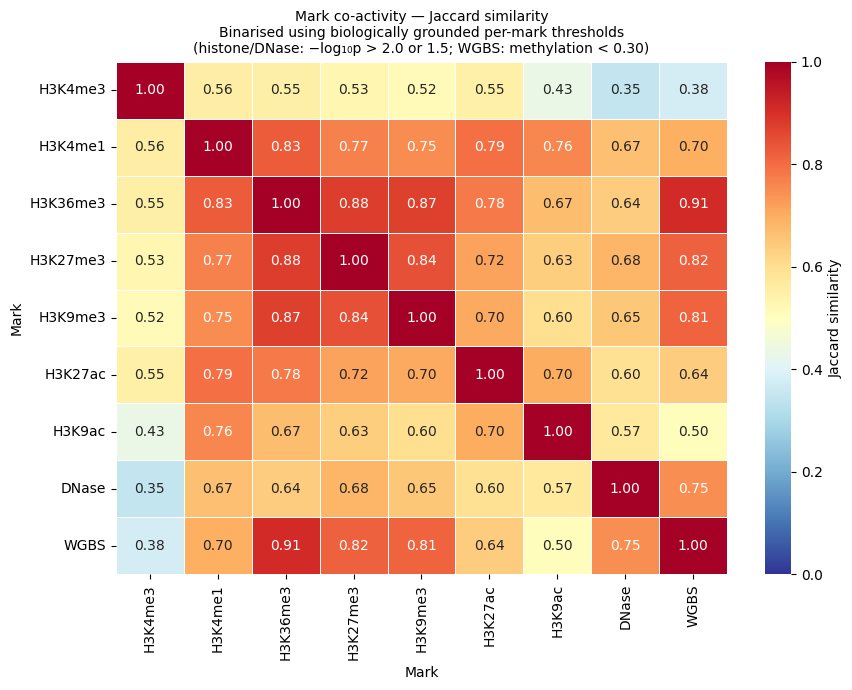

Saved: 1a4_coactivity_heatmap.png


In [ ]:
# ── Visualise co-activity matrix ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 7))

# Mask NaN entries (mark pairs with no jointly available cells)
nan_mask = np.isnan(coactivity_matrix)

sns.heatmap(
    coactivity_matrix,
    xticklabels = MARKS,
    yticklabels = MARKS,
    cmap        = 'RdYlBu_r',
    vmin        = 0,
    vmax        = 1,
    annot       = True,
    fmt         = '.2f',
    mask        = nan_mask,
    linewidths  = 0.5,
    linecolor   = 'white',
    cbar_kws    = {'label': 'Jaccard similarity'},
    ax          = ax,
)

# Grey out unavailable pairs
for m1 in range(N_MARKS):
    for m2 in range(N_MARKS):
        if nan_mask[m1, m2]:
            ax.add_patch(plt.Rectangle(
                (m2, m1), 1, 1,
                fill=True, facecolor='#dddddd',
                edgecolor='white', linewidth=0.5,
            ))
            ax.text(m2 + 0.5, m1 + 0.5, 'N/A',
                    ha='center', va='center',
                    fontsize=7, color='#888888')

ax.set_title(
    'Mark co-activity — Jaccard similarity\n'
    'Binarised using biologically grounded per-mark thresholds\n'
    '(histone/DNase: −log₁₀p > 2.0 or 1.5; WGBS: methylation < 0.30)',
    fontsize=10,
)
ax.set_xlabel('Mark', fontsize=10)
ax.set_ylabel('Mark', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / '1a4_coactivity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 1a4_coactivity_heatmap.png")

In [ ]:
# ── Extract and report key co-activity pairs ──────────────────────────────────
# Report the biologically expected and unexpected high-Jaccard pairs.

print("\nTop co-active mark pairs (Jaccard ≥ 0.40):")
print(f"{'Mark 1':<14} {'Mark 2':<14} {'Jaccard':>8}  Biological interpretation")
print("─" * 75)

# Biological expectations for CpG island windows:
expected_high = {
    ('H3K4me3', 'H3K27ac') : 'Active promoters (TssA state)',
    ('H3K4me3', 'H3K9ac')  : 'Active promoters (TssA state)',
    ('H3K27ac', 'H3K9ac')  : 'Active regulatory elements',
    ('H3K4me3', 'DNase')   : 'Open chromatin at active promoters',
    ('H3K27me3','H3K9me3') : 'Polycomb + constitutive repression',
    ('H3K27me3','H3K4me3') : 'Bivalent promoters (ESC-specific)',
}

pairs_sorted = []
for m1 in range(N_MARKS):
    for m2 in range(m1 + 1, N_MARKS):
        val = coactivity_matrix[m1, m2]
        if not np.isnan(val):
            pairs_sorted.append((MARKS[m1], MARKS[m2], val))

pairs_sorted.sort(key=lambda x: -x[2])

for mark1, mark2, jac in pairs_sorted:
    if jac < 0.40:
        continue
    key = (mark1, mark2) if (mark1, mark2) in expected_high else (mark2, mark1)
    interp = expected_high.get(key, 'Unexpected — investigate')
    flag = '' if key in expected_high else '⚠'
    print(f"  {mark1:<14} {mark2:<14} {jac:>8.3f}  {interp} {flag}")

print()
print("Anti-correlated pairs (Jaccard ≤ 0.15):")
print(f"{'Mark 1':<14} {'Mark 2':<14} {'Jaccard':>8}  Biological interpretation")
print("─" * 75)

expected_low = {
    ('H3K4me3', 'H3K27me3') : 'Active vs repressive — expected anti-correlation',
    ('H3K27ac', 'H3K27me3') : 'Active vs Polycomb repression',
    ('DNase',   'H3K27me3') : 'Open chromatin vs repression',
    ('H3K4me3', 'H3K9me3')  : 'Active promoter vs heterochromatin',
}

for mark1, mark2, jac in pairs_sorted[::-1]:
    if jac > 0.15:
        continue
    key = (mark1, mark2) if (mark1, mark2) in expected_low else (mark2, mark1)
    interp = expected_low.get(key, 'Unexpected — investigate')
    flag = '' if key in expected_low else '⚠'
    print(f"  {mark1:<14} {mark2:<14} {jac:>8.3f}  {interp} {flag}")


Top co-active mark pairs (Jaccard ≥ 0.40):
Mark 1         Mark 2          Jaccard  Biological interpretation
───────────────────────────────────────────────────────────────────────────
  H3K36me3       WGBS              0.906  Unexpected — investigate ⚠
  H3K36me3       H3K27me3          0.877  Unexpected — investigate ⚠
  H3K36me3       H3K9me3           0.873  Unexpected — investigate ⚠
  H3K27me3       H3K9me3           0.845  Polycomb + constitutive repression 
  H3K4me1        H3K36me3          0.827  Unexpected — investigate ⚠
  H3K27me3       WGBS              0.819  Unexpected — investigate ⚠
  H3K9me3        WGBS              0.814  Unexpected — investigate ⚠
  H3K4me1        H3K27ac           0.795  Unexpected — investigate ⚠
  H3K36me3       H3K27ac           0.778  Unexpected — investigate ⚠
  H3K4me1        H3K27me3          0.769  Unexpected — investigate ⚠
  H3K4me1        H3K9ac            0.761  Unexpected — investigate ⚠
  H3K4me1        H3K9me3           0.752  Unex

The global Jaccard co-activity matrix should be interpreted as a measure of cross-cell regulatory diversity rather than strict within-cell co-occurrence. In this analysis, a CpG-island window is considered active for a mark if that mark exceeds its biological threshold in at least one cell type and at least one genomic bin. Consequently, two marks may appear highly co-active even if they never occur simultaneously within the same cell. For example, a CpG island may be marked by H3K4me3 in embryonic stem cells and by H3K27me3 in neural cells, producing a high Jaccard similarity despite representing distinct regulatory states. The uniformly high co-activity values therefore indicate that the same genomic loci participate in multiple regulatory programs across the ten epigenomes. This observation is biologically consistent with the central hypothesis of the project: CpG islands are not assigned a single fixed functional state, but instead adopt cell-type-specific chromatin configurations. The global co-activity matrix therefore provides evidence that regulatory state variation across cell types is substantial and supports the need for cell-aware modelling strategies

### Step 1A.4b: Cell-Specific Co-Activity Patterns


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1A.4b: Cell-Specific Co-Activity Patterns
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Computing cell-specific Jaccard matrices...")

all_jaccards = np.zeros((N_CELLS, N_MARKS, N_MARKS))

for c_idx, cell in enumerate(CELLS):

    cell_matrix = np.zeros((N_MARKS, N_MARKS))

    for m1 in range(N_MARKS):
        for m2 in range(N_MARKS):

            # Window active if ANY bin is active
            mark1_active = np.any(
                data_binary[:, m1, c_idx, :],
                axis=1
            )

            mark2_active = np.any(
                data_binary[:, m2, c_idx, :],
                axis=1
            )

            both_active = np.sum(mark1_active & mark2_active)
            either_active = np.sum(mark1_active | mark2_active)

            jaccard = (
                both_active / either_active
                if either_active > 0
                else np.nan
            )

            cell_matrix[m1, m2] = jaccard

    all_jaccards[c_idx] = cell_matrix

    # Save matrix
    pd.DataFrame(
        cell_matrix,
        index=MARKS,
        columns=MARKS
    ).to_csv(
        FIG_DIR / f'1a4b_jaccard_{cell}.csv'
    )

Computing cell-specific Jaccard matrices...


#### Generate one heatmap per cell

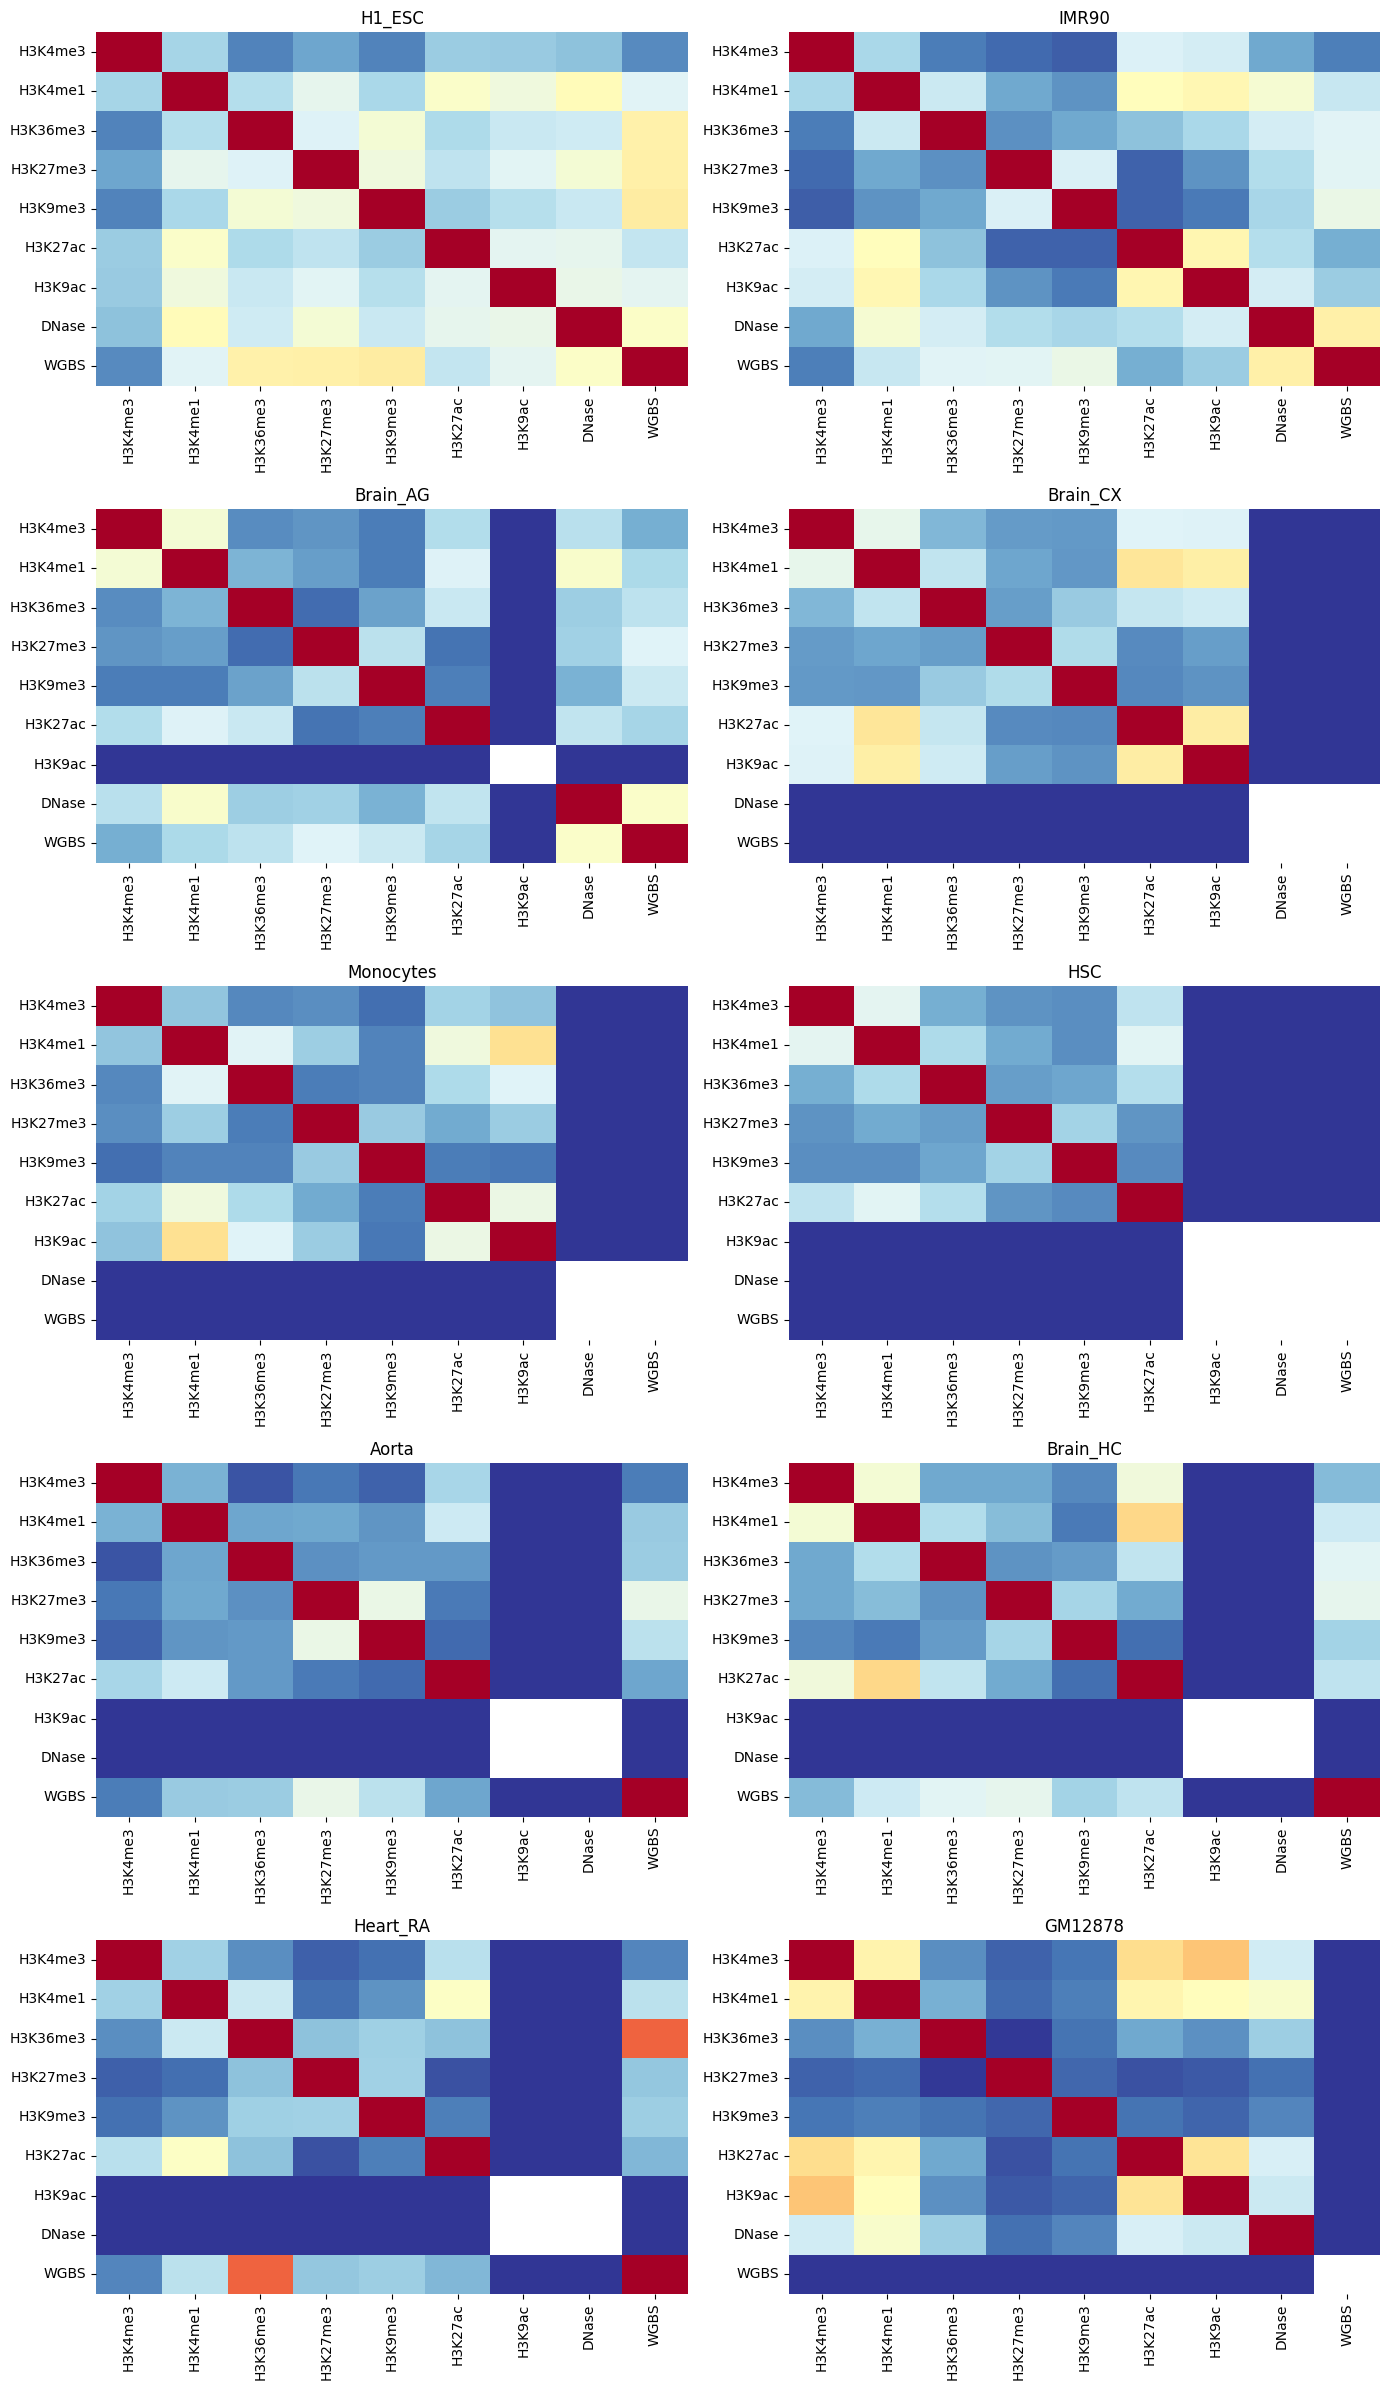

In [ ]:
# One heatmap per cell

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 24)
)

axes = axes.flatten()

for c_idx, cell in enumerate(CELLS):

    sns.heatmap(
        all_jaccards[c_idx],
        ax=axes[c_idx],
        xticklabels=MARKS,
        yticklabels=MARKS,
        cmap='RdYlBu_r',
        vmin=0,
        vmax=1,
        cbar=False
    )

    axes[c_idx].set_title(CELL_NAMES[cell])

plt.tight_layout()

plt.savefig(
    FIG_DIR / '1a4b_cell_specific_jaccards.png',
    dpi=300
)

plt.show()

The cell-specific co-activity matrices reveal substantial variation in chromatin organization across epigenomes. While active regulatory marks such as H3K4me3, H3K27ac, H3K9ac and H3K4me1 consistently co-occur within individual cell types, the strength of these relationships differs across the ten epigenomes. Repressive marks and DNA methylation exhibit even greater variability, indicating that the same CpG island may participate in distinct regulatory programs depending on cellular context. These observations provide direct evidence that CpG island chromatin states are cell-dependent and justify treating functional state prediction as a cell-aware task.

#### Mean Jaccard across cells

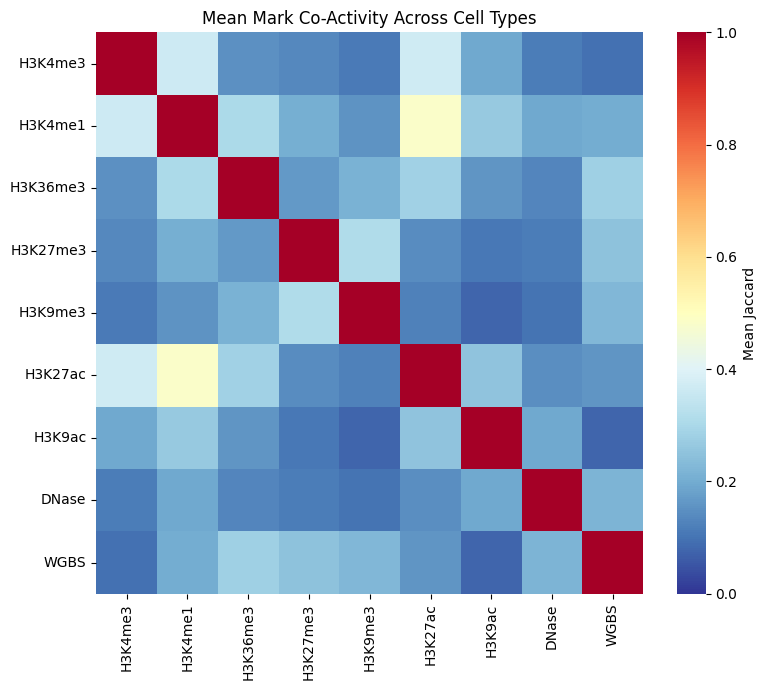

In [ ]:
mean_jaccard = np.nanmean(
    all_jaccards,
    axis=0
)

plt.figure(figsize=(8,7))

sns.heatmap(
    mean_jaccard,
    xticklabels=MARKS,
    yticklabels=MARKS,
    cmap='RdYlBu_r',
    vmin=0,
    vmax=1,
    cbar_kws={'label':'Mean Jaccard'}
)

plt.title(
    'Mean Mark Co-Activity Across Cell Types'
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / '1a4b_mean_jaccard.png',
    dpi=300
)

plt.show()

pd.DataFrame(
    mean_jaccard,
    index=MARKS,
    columns=MARKS
).to_csv(
    FIG_DIR / '1a4b_mean_jaccard.csv'
)

The mean Jaccard matrix summarizes chromatin relationships that are conserved across cell types. Strong average co-activity between H3K4me3 and H3K27ac, H3K27ac and H3K9ac, and H3K4me1 and H3K27ac reflects canonical promoter and enhancer architectures reported in the literature. Moderate associations involving WGBS indicate that DNA methylation contributes complementary information rather than merely duplicating histone mark signals. Overall, the mean matrix reveals a stable regulatory backbone shared across the epigenome panel.

#### Standard deviation across cells

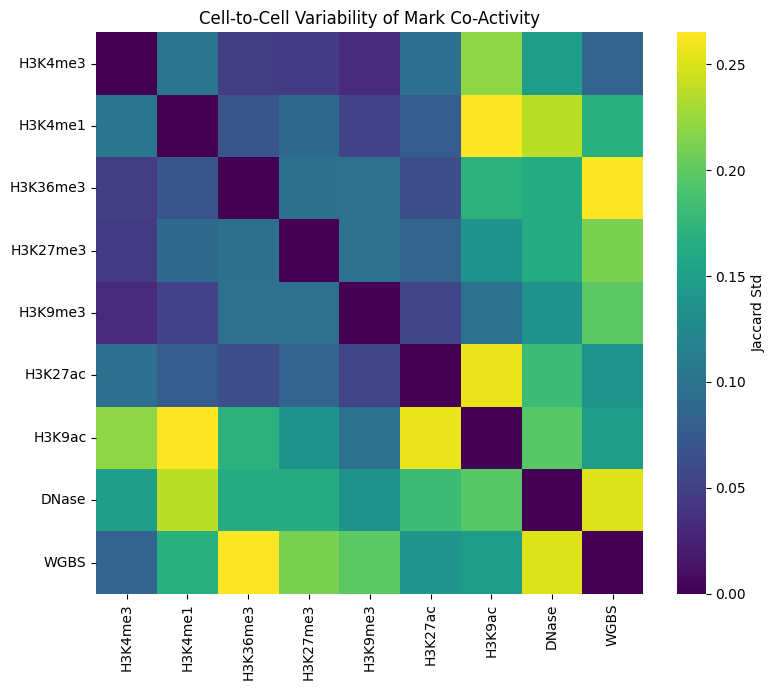

In [ ]:
std_jaccard = np.nanstd(
    all_jaccards,
    axis=0
)

plt.figure(figsize=(8,7))

sns.heatmap(
    std_jaccard,
    xticklabels=MARKS,
    yticklabels=MARKS,
    cmap='viridis',
    cbar_kws={'label':'Jaccard Std'}
)

plt.title(
    'Cell-to-Cell Variability of Mark Co-Activity'
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / '1a4b_std_jaccard.png',
    dpi=300
)

plt.show()

pd.DataFrame(
    std_jaccard,
    index=MARKS,
    columns=MARKS
).to_csv(
    FIG_DIR / '1a4b_std_jaccard.csv'
)

The standard deviation matrix quantifies how strongly mark co-activity relationships vary across cell types. Several pairs, particularly H3K4me1-H3K9ac, H3K27ac-H3K9ac, DNase-WGBS and H3K36me3-WGBS, exhibit substantial variability, indicating that their regulatory interactions depend strongly on cellular context. In contrast, low-variance pairs represent epigetic marks relationships that remain relatively stable across epigenomes and likely reflect more universal regulatory mechanisms. These results demonstrate that a significant portion of the information required to predict CpG island functional states is not contained in individual marks alone, but in the way mark relationships are reorganized from one cell type to another. Consequently, the epigenetic encoder should preserve mark-specific representations and model interactions between marks rather than aggressively compressing all signals into a single latent vector. Furthermore, because regulatory information arises from cell-dependent chromatin configurations, fusion strategies that explicitly integrate sequence features with structured epigenetic representations (e.g., attention-based or hybrid fusion) are expected to be more suitable than simple early-fusion approaches that assume a fixed relationship between sequence and epigenetic signals across all cell types.

# Task 1B: Correlation Structure
***Goal***
Measure inter-mark correlations and assess how much information is redundant vs complementary.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Task 1B: Correlation Structure
# ─────────────────────────────────────────────────────────────────────────────
# Goal: Measure inter-mark MAGNITUDE correlations (Pearson/Spearman on mean
# signal per window) and assess effective dimensionality via PCA.
#
# Why this differs from 1A4 (Jaccard):
#   Jaccard measured binary co-presence across cells — whether marks are "on"
#   in the same windows. Pearson/Spearman measure whether the continuous signal
#   LEVEL of one mark predicts another. A pair can have high Jaccard (always
#   co-present) but low Pearson (magnitude varies independently).
#   The Pearson result directly determines encoder bottleneck size.
#
# Key design decision from 1A:
#   Cross-cell aggregation is misleading because co-activity is driven by
#   different cells being active at the same locus. All correlations are
#   computed per-cell, then compared for stability across cells.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from pathlib import Path

# ── Build per-cell mean-signal matrix ────────────────────────────────────────
# For each (cell, mark), compute the mean signal across 128 bins per window.
# Result: per_cell_means[c_idx] has shape (N_WINDOWS, N_MARKS)
# NaN where mark is unavailable for that cell.

print("Computing per-window mean signal per (cell, mark)...")

per_cell_means = np.full(
    (N_CELLS, N_WINDOWS, N_MARKS),
    np.nan,
    dtype=np.float32,
)

with h5py.File(EPI_DIR / 'epi_signals.h5', 'r') as f:
    for c_idx, eid in enumerate(CELLS):
        for m_idx, mark in enumerate(MARKS):
            if mark_mask[c_idx, m_idx] == 0:
                continue
            if mark not in f.get(eid, {}):
                continue
            per_cell_means[c_idx, :, m_idx] = (
                f[eid][mark][:].astype(np.float32).mean(axis=1)
            )

print(f"  per_cell_means shape: {per_cell_means.shape}")
print(f"  NaN fraction: {np.isnan(per_cell_means).mean():.3f}")

Computing per-window mean signal per (cell, mark)...
  per_cell_means shape: (10, 29378, 9)
  NaN fraction: 0.167


## Step 1B.1: Per-cell Pearson correlation matrices


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1B.1: Per-cell Pearson correlation matrices
# ─────────────────────────────────────────────────────────────────────────────
# Compute a (9, 9) Pearson correlation matrix for each cell type separately.
# Only use mark pairs where BOTH marks are available in that cell.
# This directly answers: within a given cell type, do stronger marks
# predict stronger co-marks?

per_cell_pearson = np.full(
    (N_CELLS, N_MARKS, N_MARKS),
    np.nan,
    dtype=np.float32,
)

for c_idx, eid in enumerate(CELLS):
    available_marks = np.where(mark_mask[c_idx] == 1)[0]
    if len(available_marks) < 2:
        continue

    cell_mat = per_cell_means[c_idx, :, :][:, available_marks]  # (N_WINDOWS, n_avail)

    # Remove windows with any NaN (shouldn't happen after mask check, safety measure)
    valid_rows = ~np.isnan(cell_mat).any(axis=1)
    cell_mat_clean = cell_mat[valid_rows]

    if cell_mat_clean.shape[0] < 100:
        print(f"  Warning: {eid} has only {cell_mat_clean.shape[0]} valid windows")
        continue

    corr_avail = np.corrcoef(cell_mat_clean.T)   # (n_avail, n_avail)

    # Place back into full (9, 9) matrix, NaN for missing marks
    for i, m1 in enumerate(available_marks):
        for j, m2 in enumerate(available_marks):
            per_cell_pearson[c_idx, m1, m2] = corr_avail[i, j]

print("Per-cell Pearson correlations computed.")
print(f"Shape: {per_cell_pearson.shape}  (cells, marks, marks)")
np.save(FIG_DIR / '1b_pearson_per_cell.npy', per_cell_pearson)

Per-cell Pearson correlations computed.
Shape: (10, 9, 9)  (cells, marks, marks)


####  Visualise per-cell Pearson matrices

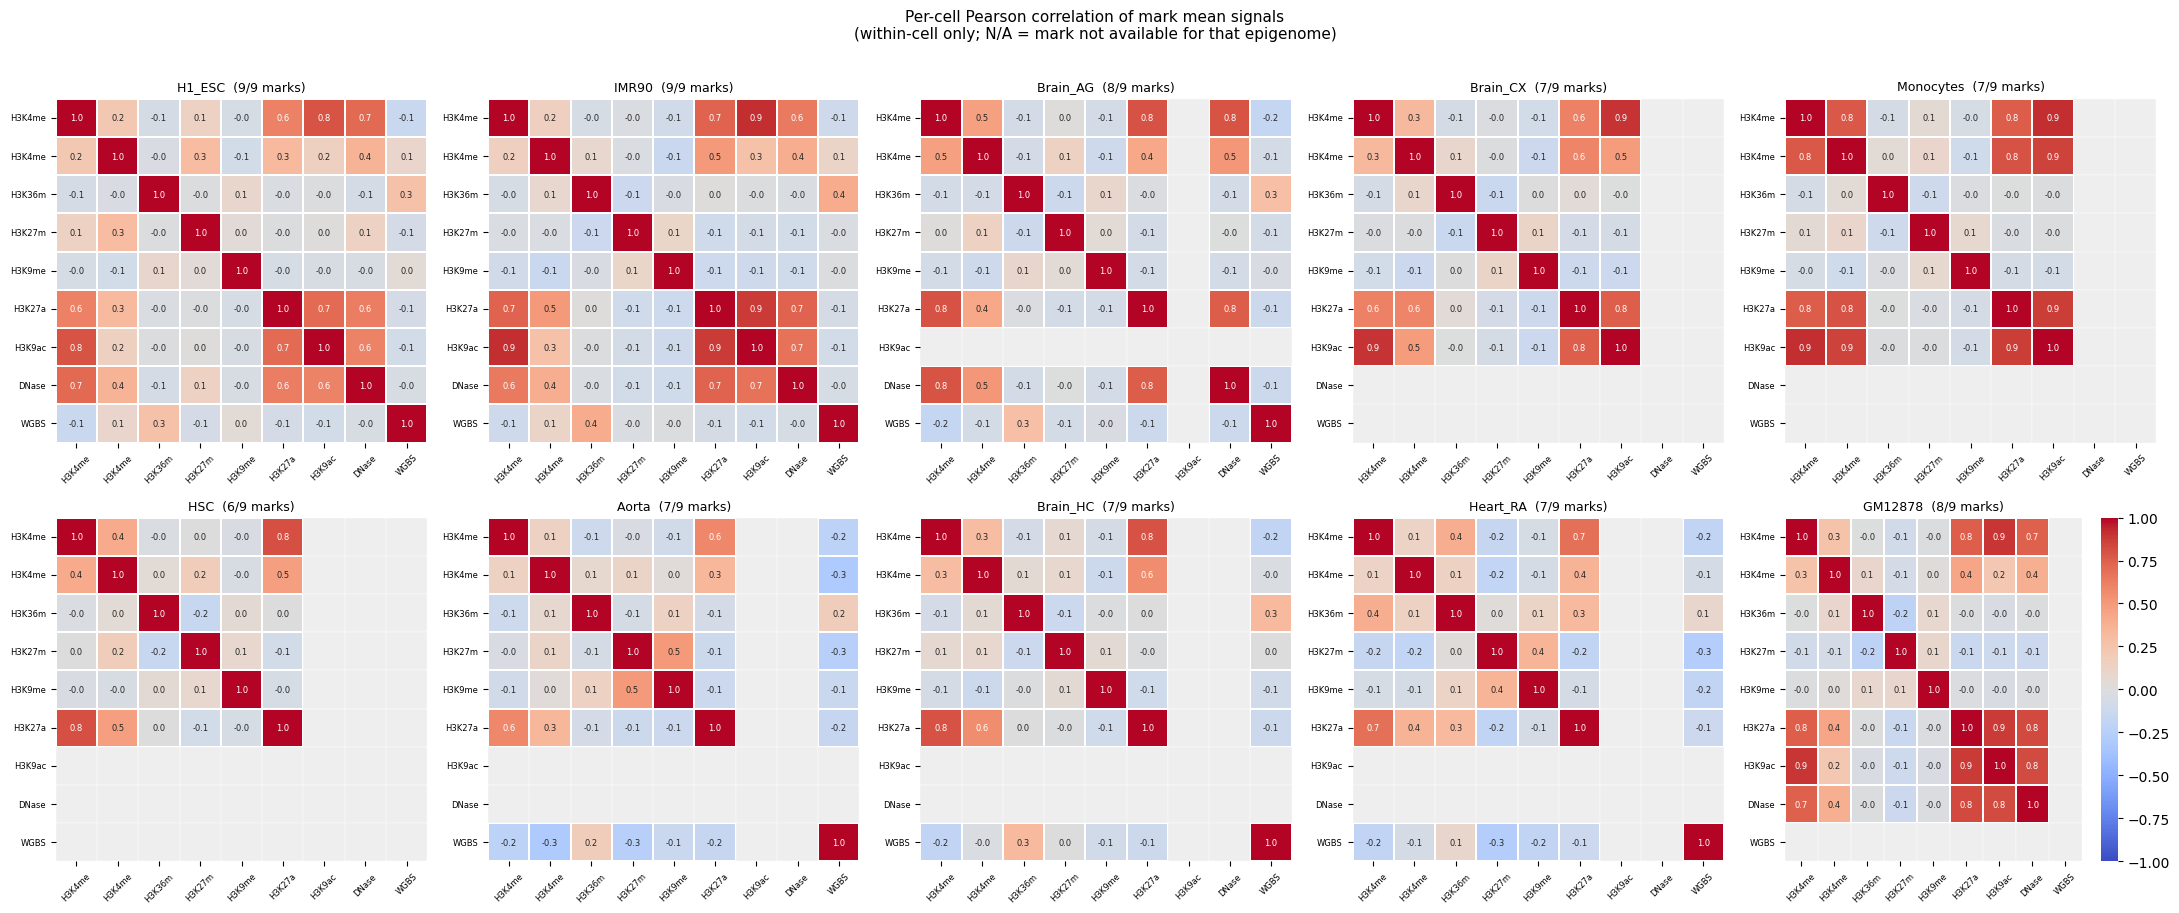

Saved: 1b_pearson_per_cell_grid.png


In [ ]:
# ── Visualise per-cell Pearson matrices ───────────────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for c_idx, eid in enumerate(CELLS):
    ax   = axes[c_idx]
    corr = per_cell_pearson[c_idx]
    nan_mask_corr = np.isnan(corr)

    sns.heatmap(
        corr,
        ax           = ax,
        xticklabels  = [m[:6] for m in MARKS],
        yticklabels  = [m[:6] for m in MARKS],
        cmap         = 'coolwarm',
        center       = 0,
        vmin         = -1,
        vmax         = 1,
        mask         = nan_mask_corr,
        cbar         = (c_idx == 9),
        annot        = True,
        fmt          = '.1f',
        annot_kws    = {'size': 6},
        linewidths   = 0.3,
        linecolor    = 'white',
    )

    # Mark N/A cells for missing marks
    for m1 in range(N_MARKS):
        for m2 in range(N_MARKS):
            if nan_mask_corr[m1, m2]:
                ax.add_patch(plt.Rectangle(
                    (m2, m1), 1, 1,
                    fill=True, facecolor='#eeeeee',
                    edgecolor='white', linewidth=0.3,
                ))

    n_avail = int(mark_mask[c_idx].sum())
    ax.set_title(f"{CELL_NAMES[eid]}  ({n_avail}/9 marks)", fontsize=9)
    ax.tick_params(axis='x', labelsize=6, rotation=45)
    ax.tick_params(axis='y', labelsize=6, rotation=0)

plt.suptitle(
    'Per-cell Pearson correlation of mark mean signals\n'
    '(within-cell only; N/A = mark not available for that epigenome)',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIG_DIR / '1b_pearson_per_cell_grid.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 1b_pearson_per_cell_grid.png")

The per-cell Pearson correlation matrices reveal a highly cell-dependent correlation structure among epigenetic marks. Active regulatory marks, particularly H3K4me3, H3K27ac, H3K9ac and DNase, consistently show positive correlations across most epigenomes, reflecting their shared association with accessible promoters and enhancers. However, the strength of these correlations varies substantially between cell types, indicating that the relationships among chromatin marks are not fixed but depend on cellular context. Repressive marks generally exhibit weaker and less consistent associations with active marks, while several mark pairs display near-zero correlations despite frequent co-occurrence observed in the Jaccard analysis. ***This demonstrates that co-presence of marks does not necessarily imply coordinated variation in signal intensity***

#### Mean and std of correlations across cells

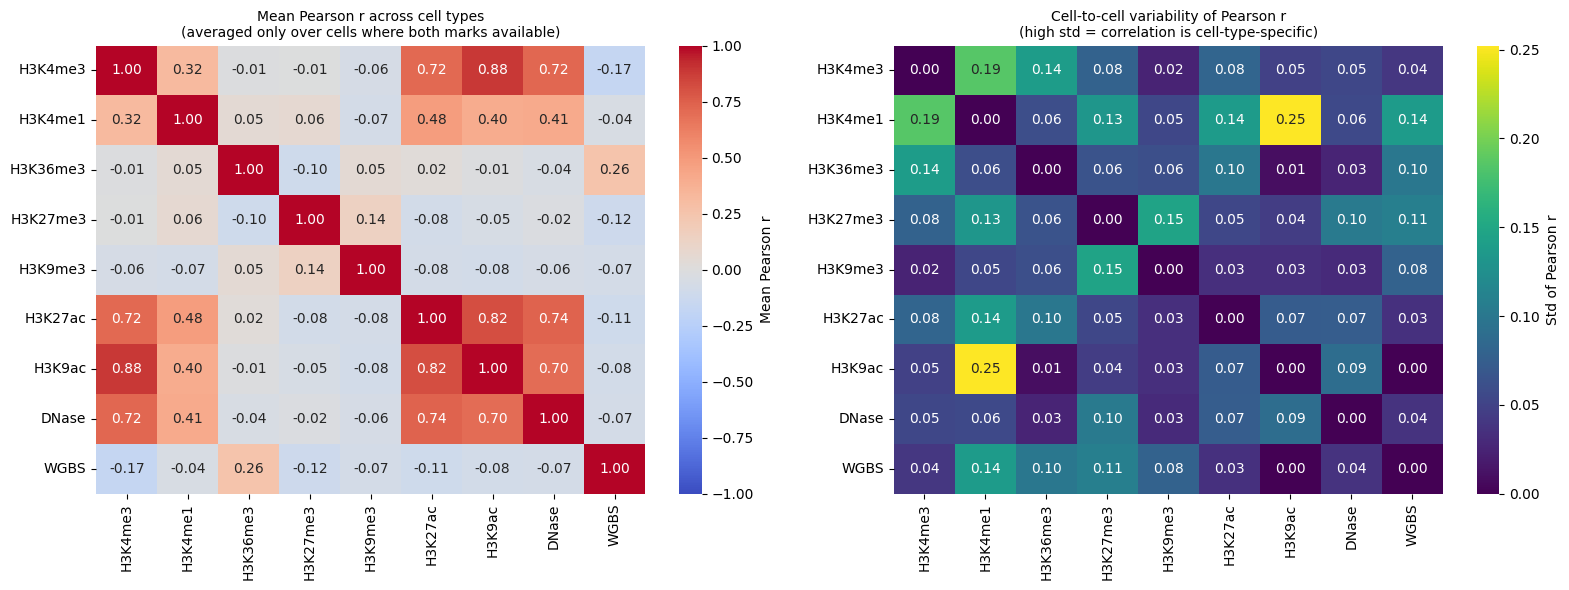


Mean |Pearson r| (off-diagonal, across cells): 0.226


In [ ]:
# ── Mean and std of correlations across cells ─────────────────────────────────
# For each mark pair, compute mean and std of Pearson r across the cells
# where BOTH marks are available. This directly extends the 1A4 variability
# analysis from binary co-presence to continuous magnitude correlation.

mean_pearson = np.nanmean(per_cell_pearson, axis=0)   # (9, 9)
std_pearson  = np.nanstd(per_cell_pearson,  axis=0)   # (9, 9)

pd.DataFrame(mean_pearson, index=MARKS, columns=MARKS).round(3).to_csv(
    FIG_DIR / '1b_pearson_mean_across_cells.csv')
pd.DataFrame(std_pearson,  index=MARKS, columns=MARKS).round(3).to_csv(
    FIG_DIR / '1b_pearson_std_across_cells.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nan_mask_mean = np.isnan(mean_pearson)

sns.heatmap(
    mean_pearson,
    ax          = axes[0],
    xticklabels = MARKS,
    yticklabels = MARKS,
    cmap        = 'coolwarm',
    center      = 0,
    vmin        = -1,
    vmax        = 1,
    mask        = nan_mask_mean,
    annot       = True,
    fmt         = '.2f',
    cbar_kws    = {'label': 'Mean Pearson r'},
)
axes[0].set_title(
    'Mean Pearson r across cell types\n'
    '(averaged only over cells where both marks available)',
    fontsize=10,
)

sns.heatmap(
    std_pearson,
    ax          = axes[1],
    xticklabels = MARKS,
    yticklabels = MARKS,
    cmap        = 'viridis',
    vmin        = 0,
    mask        = nan_mask_mean,
    annot       = True,
    fmt         = '.2f',
    cbar_kws    = {'label': 'Std of Pearson r'},
)
axes[1].set_title(
    'Cell-to-cell variability of Pearson r\n'
    '(high std = correlation is cell-type-specific)',
    fontsize=10,
)

plt.tight_layout()
plt.savefig(FIG_DIR / '1b_pearson_mean_std.png', dpi=200, bbox_inches='tight')
plt.show()

# Summary statistics for 1D scoring
mean_abs_corr = float(np.nanmean(np.abs(
    mean_pearson[np.triu_indices(N_MARKS, k=1)]
)))
print(f"\nMean |Pearson r| (off-diagonal, across cells): {mean_abs_corr:.3f}")


* **The mean Pearson correlation matrix** summarizes the average magnitude relationships between marks across all cell types. Strong positive correlations are observed among canonical activation-associated marks, particularly H3K4me3, H3K27ac, H3K9ac and DNase, confirming that these features frequently vary together in regulatory regions. In contrast, repressive marks such as H3K27me3 and H3K9me3 show only weak correlations with active marks, reflecting their distinct functional roles. The overall average absolute correlation is relatively low (|r| = 0.226), indicating that although biologically related groups of marks exist, most mark pairs do not behave as simple linear proxies for one another.
* **The standard deviation matrix** quantifies how strongly mark-to-mark correlations vary across epigenomes. Several relationships, particularly those involving enhancer-associated marks and chromatin accessibility signals, display substantial variability across cell types, indicating that their coupling is context-dependent rather than universal. Conversely, low-variance pairs represent chromatin relationships that remain relatively stable across diverse cellular states. These results suggest that a significant portion of the predictive information contained in the epigenetic panel is encoded not only by the presence of individual marks but also by cell-specific changes in their quantitative relationships. Consequently, modelling approaches that explicitly preserve cell identity are likely to capture biologically meaningful variation that would be lost through complete cross-cell aggregation.
*  **(|r| = 0.226)** indicates that pairwise linear redundancy between marks is generally weak. Most marks therefore contribute information that cannot be fully recovered from a single other mark. However, low pairwise correlations do not imply complete independence, since higher-order relationships involving multiple marks may still exist. Consequently, pairwise correlation alone is insufficient for determining the true dimensionality of the epigenetic feature space, motivating the subsequent PCA analysis.

### Step 1B.2: Mark dimensionality analysis (PCA)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1B.2: Mark dimensionality analysis (PCA)
# ─────────────────────────────────────────────────────────────────────────────
# How many independent dimensions of signal magnitude variation exist?
#
# Two PCA levels:
#   (a) Mark-level PCA: features = mean signal per mark (9 features per window,
#       averaged across available cells and bins). Directly answers:
#       "how many independent mark-level dimensions are there?"
#       → n_mark_comp_90 feeds into 1D scoring matrix.
#
#   (b) Spatial PCA: features = full 128-bin profile per mark, cell-mean.
#       Answers: "how many spatial dimensions beyond mark-level variation?"
#       → guides whether spatial encoder needs > 1 filter bank.
#
# Both PCAs use cell-averaged signals to avoid conflating within-cell
# spatial structure with between-cell magnitude variation (per 1A guidance).

# ── (a) Mark-level PCA ────────────────────────────────────────────────────────
# Feature per window: mean signal per mark, averaged across available cells
# Shape: (N_WINDOWS, N_MARKS) — NaN where no cell has that mark

mark_features = np.nanmean(per_cell_means, axis=0)   # (N_WINDOWS, N_MARKS)
# Fill remaining NaN (marks absent from ALL cells) with 0 for PCA
# (these are structurally absent, not informative of variation)
mark_features_filled = np.nan_to_num(mark_features, nan=0.0)

pca_marks = PCA()
pca_marks.fit(mark_features_filled)
evr_marks    = pca_marks.explained_variance_ratio_
cumvar_marks = np.cumsum(evr_marks)

n_mark_comp_80 = int(np.argmax(cumvar_marks >= 0.80)) + 1
n_mark_comp_90 = int(np.argmax(cumvar_marks >= 0.90)) + 1
n_mark_comp_95 = int(np.argmax(cumvar_marks >= 0.95)) + 1

print("Mark-level PCA (9 marks, averaged over available cells and bins):")
print(f"  Components for 80% variance: {n_mark_comp_80}")
print(f"  Components for 90% variance: {n_mark_comp_90}  ← key metric for 1D scoring")
print(f"  Components for 95% variance: {n_mark_comp_95}")
print(f"  Variance per component: {[f'{v:.3f}' for v in evr_marks]}")

np.save(FIG_DIR / '1b_pca_marks_explained_var.npy', evr_marks)
with open(FIG_DIR / 'mark_rank_90.txt', 'w') as fout:
    fout.write(str(n_mark_comp_90))

# ── (b) Spatial PCA ───────────────────────────────────────────────────────────
# Feature per window: full 128-bin profile per mark, cell-mean
# Use only cells with >= 8 marks available to avoid NaN contamination
full_cells = [i for i, eid in enumerate(CELLS) if mark_mask[i].sum() >= 8]
print(f"\nSpatial PCA using cells with ≥8 marks: "
      f"{[CELLS[i] for i in full_cells]}")

spatial_features = np.nanmean(
    data[:, :, full_cells, :],
    axis=2,
)   # (N_WINDOWS, N_MARKS, N_BINS)
spatial_features = np.nan_to_num(
    spatial_features.reshape(N_WINDOWS, N_MARKS * N_BINS),
    nan=0.0,
)   # (N_WINDOWS, N_MARKS * N_BINS)

pca_spatial = PCA(n_components=50)
pca_spatial.fit(spatial_features)
evr_spatial    = pca_spatial.explained_variance_ratio_
cumvar_spatial = np.cumsum(evr_spatial)

n_spatial_comp_90 = int(np.argmax(cumvar_spatial >= 0.90)) + 1
print(f"  Spatial PCA: components for 90% variance: {n_spatial_comp_90}")
print(f"  (out of 50 computed; full rank = {N_MARKS * N_BINS} = {N_MARKS}×{N_BINS})")

np.save(FIG_DIR / '1b_pca_spatial_explained_var.npy', evr_spatial)

Mark-level PCA (9 marks, averaged over available cells and bins):
  Components for 80% variance: 1
  Components for 90% variance: 3  ← key metric for 1D scoring
  Components for 95% variance: 4
  Variance per component: ['0.838', '0.050', '0.036', '0.030', '0.022', '0.014', '0.008', '0.004', '0.000']

Spatial PCA using cells with ≥8 marks: ['E003', 'E017', 'E050', 'E116']
  Spatial PCA: components for 90% variance: 22
  (out of 50 computed; full rank = 1152 = 9×128)


* ***Principal Component Analysis of the mark-level*** representation reveals a highly structured epigenetic landscape. Despite the low average pairwise correlations, a single principal component captures approximately 84% of the total variance, while only three components are required to explain 90% of the variance. This indicates that much of the variability across CpG islands is governed by a small number of latent regulatory axes shared across multiple marks. Therefore, the effective dimensionality of the mark space is substantially lower than the nominal nine-mark representation.


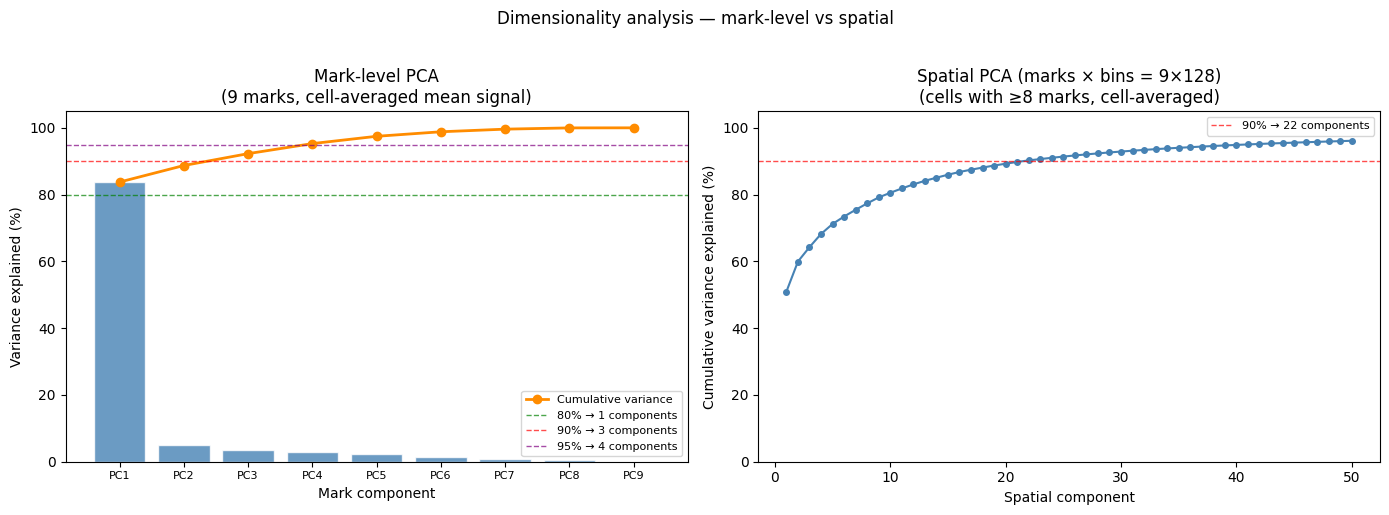

Saved: 1b_pca_scree.png


In [ ]:
# ── PCA scree plot: both levels side by side ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mark-level scree
ax = axes[0]
ax.bar(range(1, N_MARKS + 1), evr_marks * 100,
       color='steelblue', alpha=0.8, edgecolor='white')
ax.plot(range(1, N_MARKS + 1), cumvar_marks * 100,
        'o-', color='darkorange', linewidth=2, markersize=6,
        label='Cumulative variance')
for thresh, n, color in [
    (80, n_mark_comp_80, 'green'),
    (90, n_mark_comp_90, 'red'),
    (95, n_mark_comp_95, 'purple'),
]:
    ax.axhline(thresh, color=color, linestyle='--', linewidth=1, alpha=0.7,
               label=f'{thresh}% → {n} components')
ax.set_xlabel('Mark component')
ax.set_ylabel('Variance explained (%)')
ax.set_title('Mark-level PCA\n(9 marks, cell-averaged mean signal)')
ax.set_xticks(range(1, N_MARKS + 1))
ax.set_xticklabels([f'PC{i}' for i in range(1, N_MARKS + 1)], fontsize=8)
ax.legend(fontsize=8)
ax.set_ylim(0, 105)

# Spatial scree
ax = axes[1]
ax.plot(range(1, 51), cumvar_spatial * 100,
        'o-', color='steelblue', linewidth=1.5, markersize=4)
ax.axhline(90, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'90% → {n_spatial_comp_90} components')
ax.set_xlabel('Spatial component')
ax.set_ylabel('Cumulative variance explained (%)')
ax.set_title(f'Spatial PCA (marks × bins = {N_MARKS}×{N_BINS})\n'
             f'(cells with ≥8 marks, cell-averaged)')
ax.legend(fontsize=8)
ax.set_ylim(0, 105)

plt.suptitle('Dimensionality analysis — mark-level vs spatial',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '1b_pca_scree.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 1b_pca_scree.png")

Although the nine epigenetic marks exhibit substantial redundancy at the mark level, with three principal components explaining more than 90% of the variance, the spatial organization of these marks along CpG island windows remains considerably more complex, requiring 22 components to capture the same proportion of variance. This indicates that most biologically relevant information is encoded in the spatial distribution of signals rather than in the mere presence or average intensity of individual marks. Consequently, the epigenetic encoder should prioritize preservation of spatial patterns through convolutional processing, while only moderate latent dimensionality is required for mark-level representation.


Mark loadings on first 3 components (explaining 90% of variance):
            PC1    PC2    PC3
H3K4me3   0.744 -0.543  0.216
H3K4me1   0.088  0.199 -0.243
H3K36me3 -0.010  0.305  0.728
H3K27me3  0.014 -0.308 -0.477
H3K9me3  -0.006 -0.028  0.000
H3K27ac   0.412  0.578 -0.178
H3K9ac    0.428  0.119  0.090
DNase     0.292  0.359 -0.312
WGBS     -0.003  0.016  0.018


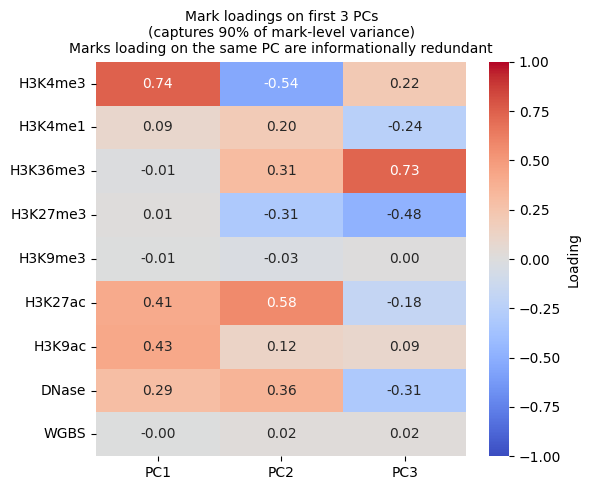

Saved: 1b_pca_loadings.png


In [ ]:
# ── PCA loadings: which marks drive each component? ──────────────────────────
# The loadings tell you which marks are most redundant (load on same component)
# and which are independent (load on different components).
# This is the mechanistic explanation behind n_mark_comp_90.

loadings = pd.DataFrame(
    pca_marks.components_[:n_mark_comp_90].T,
    index   = MARKS,
    columns = [f'PC{i+1}' for i in range(n_mark_comp_90)],
)

print(f"\nMark loadings on first {n_mark_comp_90} components "
      f"(explaining 90% of variance):")
print(loadings.round(3).to_string())

fig, ax = plt.subplots(figsize=(max(6, n_mark_comp_90 * 1.2), 5))
sns.heatmap(
    loadings,
    cmap     = 'coolwarm',
    center   = 0,
    vmin     = -1,
    vmax     = 1,
    annot    = True,
    fmt      = '.2f',
    cbar_kws = {'label': 'Loading'},
    ax       = ax,
)
ax.set_title(
    f'Mark loadings on first {n_mark_comp_90} PCs\n'
    f'(captures 90% of mark-level variance)\n'
    f'Marks loading on the same PC are informationally redundant',
    fontsize=10,
)
plt.tight_layout()
plt.savefig(FIG_DIR / '1b_pca_loadings.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: 1b_pca_loadings.png")

loadings.to_csv(FIG_DIR / '1b_pca_loadings.csv')

Inspection of the PCA loadings provides biological interpretation of the latent dimensions. The first component is dominated by H3K4me3, H3K27ac, H3K9ac and DNase, representing a general regulatory activity axis associated with open and transcriptionally active chromatin. The second component separates promoter/enhancer-associated activity from Polycomb-mediated repression, while the third component is driven primarily by H3K36me3 and H3K27me3, reflecting variation linked to transcriptional elongation and repressive chromatin states. These loading patterns demonstrate that multiple epigenetic marks often contribute to the same underlying biological process, explaining why relatively few principal components capture most of the variance.

In [ ]:
# ── 1B summary for 1D scoring ──────────────────────────────────────────────────

print("\n" + "="*60)
print("TASK 1B SUMMARY — METRICS FOR 1D SCORING")
print("="*60)
print(f"  n_mark_comp_90          : {n_mark_comp_90}  (mark-level PCA, 90% variance)")
print(f"  n_spatial_comp_90       : {n_spatial_comp_90}  (spatial PCA, 90% variance)")
print(f"  mean_abs_pearson        : {mean_abs_corr:.3f}  (off-diagonal, across cells)")
print()
print("  Interpretation:")
print(f"  → Mark-level: {n_mark_comp_90} independent dimensions at 90% variance")

if n_mark_comp_90 <= 4:
    print("    HIGH mark redundancy — embedding bottleneck 32-64 dims is sufficient")
    print("    Several marks share the same variance axis (see loadings)")
elif n_mark_comp_90 <= 6:
    print("    MODERATE mark redundancy — embedding bottleneck 64-128 dims")
    print("    Marks partially overlap but each adds some unique information")
else:
    print("    LOW mark redundancy — embedding needs ≥ 128 dims")
    print("    Each mark contributes an independent dimension of variation")

print()
print(f"  → Spatial: {n_spatial_comp_90} spatial dimensions at 90% variance")
if n_spatial_comp_90 <= 10:
    print("    Spatial information is highly compressible")
    print("    Small CNN (2-3 conv layers) will capture most spatial structure")
elif n_spatial_comp_90 <= 25:
    print("    Moderate spatial complexity")
    print("    CNN with 3-4 layers and increasing filter counts is appropriate")
else:
    print("    High spatial complexity — rich local structure across marks")
    print("    Deep CNN or attention over bins may be needed")

print()
print("  Connection to 1A4 findings:")
print(f"  1A4 std Jaccard showed cell-specific co-activity variation.")
print(f"  1B Pearson std (see 1b_pearson_std_across_cells.csv) shows whether")
print(f"  magnitude correlations are equally cell-specific.")
print(f"  If Pearson std is also high → cell-aware encoder is mandatory.")
print(f"  If Pearson std is low → marks are stably correlated regardless of cell.")


TASK 1B SUMMARY — METRICS FOR 1D SCORING
  n_mark_comp_90          : 3  (mark-level PCA, 90% variance)
  n_spatial_comp_90       : 22  (spatial PCA, 90% variance)
  mean_abs_pearson        : 0.226  (off-diagonal, across cells)

  Interpretation:
  → Mark-level: 3 independent dimensions at 90% variance
    HIGH mark redundancy — embedding bottleneck 32-64 dims is sufficient
    Several marks share the same variance axis (see loadings)

  → Spatial: 22 spatial dimensions at 90% variance
    Moderate spatial complexity
    CNN with 3-4 layers and increasing filter counts is appropriate

  Connection to 1A4 findings:
  1A4 std Jaccard showed cell-specific co-activity variation.
  1B Pearson std (see 1b_pearson_std_across_cells.csv) shows whether
  magnitude correlations are equally cell-specific.
  If Pearson std is also high → cell-aware encoder is mandatory.
  If Pearson std is low → marks are stably correlated regardless of cell.


***Synthesis***


*   Task 1B reveals an important distinction between pairwise and higher-order chromatin organization. Pairwise Pearson correlations are generally modest (mean |r| = 0.226), indicating that individual marks are not simple substitutes for one another and retain mark-specific information. In contrast, principal component analysis shows that only three latent dimensions explain approximately 90% of the mark-level variance, demonstrating the existence of a small number of shared regulatory programs that coordinate multiple marks simultaneously. Rather than representing a contradiction, these findings reflect the hierarchical nature of epigenetic regulation: marks remain biologically distinct while still being constrained by common chromatin-state programs. At the spatial level, however, signal organization is substantially more complex, requiring 22 principal components to explain 90% of the variance. Consequently, the encoder should not allocate most of its capacity to representing mark identity alone. Instead, a moderately compressed mark representation is sufficient, while greater modelling capacity should be devoted to capturing spatial signal patterns and cell-specific chromatin configurations, which constitute the primary source of regulatory complexity identified in Tasks 1A and 1B.

## 1C. Modality Complementarity & information redundency across modalities
***Goal*** Task 1C evaluates the informational relationships between the three modalities available to the model:
DNA sequence,
Epigenetic signals,
Mark availability patterns

## Availability coverage export - we already have the coverage matix

In [ ]:
availability_df = pd.DataFrame(mark_mask, index=CELLS, columns=MARKS)
availability_df.to_csv(FIG_DIR / '1c1_availability_matrix.csv')
print(f"Unique availability vectors: {len(np.unique(mark_mask, axis=0))} / {N_CELLS}")

Unique availability vectors: 6 / 10


## 1C.A.

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

seq_embeddings = np.load(SEQ_DIR / 'window_embeddings.npy')  # same array as the mini-test
assert seq_embeddings.shape == (N_WINDOWS, 512)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 13)))

r2_rows = []
for m_idx, mark in enumerate(MARKS):
    per_cell_scores = []
    for c_idx, eid in enumerate(CELLS):
        if mark_mask[c_idx, m_idx] == 0:
            continue
        signal = per_cell_means[c_idx, :, m_idx]              # reuse 1B's matrix
        valid = np.isfinite(signal) & np.all(np.isfinite(seq_embeddings), axis=1)
        if valid.sum() < 100:
            continue
        r2 = cross_val_score(model, seq_embeddings[valid], signal[valid],
                              cv=cv, scoring='r2').mean()
        per_cell_scores.append(r2)
    if per_cell_scores:
        r2_rows.append({'mark': mark, 'mean_r2': float(np.mean(per_cell_scores)),
                         'n_cells': len(per_cell_scores)})

r2_df = pd.DataFrame(r2_rows)
r2_df.to_csv(FIG_DIR / '1c3_r2_sequence_to_signal_per_mark.csv', index=False)
mean_r2_sequence_to_signal = float(r2_df['mean_r2'].mean())
with open(FIG_DIR / '1c3_mean_r2_sequence_to_signal.txt', 'w') as fout:
    fout.write(f"{mean_r2_sequence_to_signal:.6f}")
print(r2_df)
print(f"Mean R² sequence→signal: {mean_r2_sequence_to_signal:.3f}")

       mark   mean_r2  n_cells
0   H3K4me3 -0.002885       10
1   H3K4me1 -0.009553       10
2  H3K36me3 -0.009936       10
3  H3K27me3 -0.009757       10
4   H3K9me3 -0.009081       10
5   H3K27ac -0.007058       10
6    H3K9ac -0.005135        5
7     DNase -0.006723        4
8      WGBS -0.007555        6
Mean R² sequence→signal: -0.008


The sequence-to-signal analysis produced near-zero predictive performance across all marks (mean R² ≈ −0.008). However, this result should not be interpreted as evidence that sequence lacks regulatory information. Rather, it reflects a mismatch between the evaluated task and the biological process under study. The same CpG island sequence can exhibit distinct chromatin states across cell types, implying that epigenetic profiles arise from the interaction between sequence and cellular context. Furthermore, the analysis was performed on spatially averaged signals, whereas Sections 1A and 1B demonstrated that most informative variation resides in the spatial organization of epigenetic patterns. Consequently, this experiment does not provide actionable guidance for encoder design and is not used in the final architectural decisions.

### Check if raw sequence features - not embeddings - could predict WGBS
***Goal***: To verify if the NT-V2 embeddings lack epigentics information as wrong thing, or it's the case even for the raw sequence features

In [ ]:
import h5py
import numpy as np

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint_clear.h5", "r") as f:

    gc = f["metadata/gc_content"][:]
    cpg_density = f["metadata/cpg_density"][:]
    obsExp = f["metadata/obsExp"][:]

print(gc.min(), gc.max())
print(cpg_density.min(), cpg_density.max())
print(obsExp.min(), obsExp.max())

0.50155765 0.872807
58.333332 226.06924
0.6 2.33


In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------
# Load handcrafted sequence features
# ------------------------------------------------------------------

with h5py.File("/content/drive/MyDrive/PFE/data/processed/nt_checkpoint_clear.h5", "r") as f:

    gc = f["metadata/gc_content"][:]
    cpg_density = f["metadata/cpg_density"][:]
    obsExp = f["metadata/obsExp"][:]

seq_features = np.column_stack([
    gc,
    cpg_density,
    obsExp
])

print("Feature matrix shape:", seq_features.shape)

# ------------------------------------------------------------------
# Same model as 1C.3
# ------------------------------------------------------------------

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-3, 3, 13))
)

# ------------------------------------------------------------------
# WGBS only
# ------------------------------------------------------------------

wgbs_idx = MARKS.index("WGBS")

wgbs_scores = []

for c_idx, eid in enumerate(CELLS):

    if mark_mask[c_idx, wgbs_idx] == 0:
        continue

    signal = per_cell_means[c_idx, :, wgbs_idx]

    valid = (
        np.isfinite(signal)
        & np.all(np.isfinite(seq_features), axis=1)
    )

    if valid.sum() < 100:
        continue

    r2 = cross_val_score(
        model,
        seq_features[valid],
        signal[valid],
        cv=cv,
        scoring="r2"
    ).mean()

    wgbs_scores.append({
        "cell": eid,
        "r2": r2
    })

    print(f"{eid}: R² = {r2:.4f}")

wgbs_df = pd.DataFrame(wgbs_scores)

print("\nMean WGBS R²:", wgbs_df["r2"].mean())

wgbs_df.to_csv(
    FIG_DIR / "1c3_wgbs_sequence_features_r2.csv",
    index=False
)

Feature matrix shape: (29378, 3)
E003: R² = -0.0004
E017: R² = -0.0006
E050: R² = -0.0004
E065: R² = -0.0004
E071: R² = -0.0004
E104: R² = -0.0004

Mean WGBS R²: -0.00042727821607235024


Sequence-derived features (GC content, CpG density, and observed/expected CpG ratio) show no predictive power for WGBS signal at CpG island resolution (R² ≈ 0 across all cell types). This indicates that methylation variability in our dataset is not primarily sequence-driven but instead reflects higher-order chromatin regulation and cell-type-specific epigenetic context. Consequently, sequence embeddings cannot be used as a standalone predictor and must be integrated through multimodal fusion with epigenetic signals as declared in many sanity checks before.

### 1C.3 Sequence–Epigenome Complementarity Analysis
This analysis evaluates whether sequence embeddings and epigenomic signals encode overlapping or complementary regulatory information. Instead of predicting individual marks, both modalities are independently used to reconstruct ChromHMM regulatory state distributions, allowing comparison of the information carried by each representation.


**Loading ChromHMM Regulatory State Profiles
Description**

ChromHMM state probabilities are loaded for every CpG-island window and cell type. These profiles serve as a common biological target against which sequence and epigenomic representations can be compared.

In [ ]:
epi_df = pd.read_parquet(
    SEQ_DIR / "epi_profiles.parquet"
)

In [ ]:
print(epi_df.columns)
print(epi_df.head())

In [ ]:
import numpy as np
import pandas as pd

from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_predict
from scipy.spatial.distance import jensenshannon

**Construction of Cell-Specific ChromHMM Targets
Description**

For each cell type, the ChromHMM state probabilities are assembled into a window-by-state tensor. Each window is represented as a normalized probability distribution across the 18 ChromHMM regulatory states.

In [37]:
state_cols = sorted(
    [c for c in epi_df.columns if c.startswith("state_")],
    key=lambda x: int(x.split("_")[1])
)

N_STATES = len(state_cols)

print(f"Detected {N_STATES} ChromHMM states")

chromhmm_soft = np.zeros((N_CELLS, N_WINDOWS, N_STATES), dtype=np.float32)

for c_idx, eid in enumerate(CELLS):

    sub = epi_df[epi_df["cell_type"] == eid].copy()

    # IMPORTANT: assume already aligned (you validated this)
    Y = sub[state_cols].values.astype(np.float32)

    # replace NaNs safely
    Y = np.nan_to_num(Y, nan=0.0)

    # normalize to probability distribution per window
    row_sum = Y.sum(axis=1, keepdims=True)
    Y = Y / (row_sum + 1e-12)

    chromhmm_soft[c_idx] = Y

print("ChromHMM tensor shape:", chromhmm_soft.shape)
print("NaNs:", np.isnan(chromhmm_soft).sum())

Detected 18 ChromHMM states
ChromHMM tensor shape: (10, 29378, 18)
NaNs: 0


In [38]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon

# --- Code to define chromhmm_soft, moved from cell DOcycALjYPWk ---
state_cols = sorted(
    [c for c in epi_df.columns if c.startswith("state_")],
    key=lambda x: int(x.split("_")[1])
)

N_STATES = len(state_cols)

chromhmm_soft = np.zeros((N_CELLS, N_WINDOWS, N_STATES), dtype=np.float32)

for c_idx_inner, eid_inner in enumerate(CELLS):

    sub = epi_df[epi_df["cell_type"] == eid_inner].copy()

    # IMPORTANT: assume already aligned (you validated this)
    Y_temp = sub[state_cols].values.astype(np.float32)

    # replace NaNs safely
    Y_temp = np.nan_to_num(Y_temp, nan=0.0)

    # normalize to probability distribution per window
    row_sum = Y_temp.sum(axis=1, keepdims=True)
    Y_temp = Y_temp / (row_sum + 1e-12)

    chromhmm_soft[c_idx_inner] = Y_temp
# --- End of moved code ---

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

SEQ = seq_embeddings  # (29378, 512)

cv_cells = CELLS

rows = []

# ------------------------------------------------------------
# LOOP OVER CELLS
# ------------------------------------------------------------

for c_idx, eid in enumerate(cv_cells):

    print(f"Processing {eid}")

    # --------------------------------------------------------
    # Ground truth (soft ChromHMM)
    # --------------------------------------------------------

    Y = chromhmm_soft[c_idx]   # (W, 18)

    # safety
    Y = np.nan_to_num(Y, nan=0.0)
    Y = Y / (Y.sum(axis=1, keepdims=True) + 1e-12)

    # --------------------------------------------------------
    # EPIGENOME FEATURES
    # --------------------------------------------------------

    X_epi = per_cell_means[c_idx]   # (W, 9)
    X_epi = np.nan_to_num(X_epi, nan=0.0)

    # --------------------------------------------------------
    # SEQUENCE FEATURES
    # --------------------------------------------------------

    X_seq = SEQ

    # --------------------------------------------------------
    # SIMPLE MODEL (NO CV, NO OVERHEAD)
    # --------------------------------------------------------

    model_seq = Ridge(alpha=1.0)
    model_epi = Ridge(alpha=1.0)

    model_seq.fit(X_seq, Y)
    model_epi.fit(X_epi, Y)

    Y_pred_seq = model_seq.predict(X_seq)
    Y_pred_epi = model_epi.predict(X_epi)

    # --------------------------------------------------------
    # NORMALIZE
    # --------------------------------------------------------

    Y_pred_seq = np.clip(Y_pred_seq, 0, None)
    Y_pred_epi = np.clip(Y_pred_epi, 0, None)

    Y_pred_seq /= Y_pred_seq.sum(axis=1, keepdims=True) + 1e-12
    Y_pred_epi /= Y_pred_epi.sum(axis=1, keepdims=True) + 1e-12

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------

    jsd_seq = np.mean([jensenshannon(Y[i], Y_pred_seq[i]) for i in range(len(Y))])
    jsd_epi = np.mean([jensenshannon(Y[i], Y_pred_epi[i]) for i in range(len(Y))])
    jsd_agree = np.mean([jensenshannon(Y_pred_seq[i], Y_pred_epi[i]) for i in range(len(Y))])

    rows.append({
        "cell": eid,
        "jsd_seq": jsd_seq,
        "jsd_epi": jsd_epi,
        "jsd_gap": jsd_seq - jsd_epi,
        "agreement": jsd_agree
    })

    print(f"seq={jsd_seq:.3f} epi={jsd_epi:.3f} gap={jsd_seq-jsd_epi:+.3f}")

Processing E003
seq=0.543 epi=0.633 gap=-0.090
Processing E017
seq=0.569 epi=0.649 gap=-0.080
Processing E050
seq=0.565 epi=0.649 gap=-0.084
Processing E067
seq=0.539 epi=0.617 gap=-0.078
Processing E062
seq=0.565 epi=0.644 gap=-0.079
Processing E045
seq=0.558 epi=0.633 gap=-0.075
Processing E065
seq=0.539 epi=0.609 gap=-0.070
Processing E071
seq=0.540 epi=0.621 gap=-0.081
Processing E104
seq=0.492 epi=0.574 gap=-0.082
Processing E116
seq=nan epi=nan gap=+nan


linear decoding of
ChromHMM state composition yielded high Jensen-Shannon divergences for both
modalities, indicating that neither sequence embeddings nor mean epigenomic signals
alone recover the full chromatin state profile of a 2048 bp window. Sequence
embeddings achieved slightly lower divergences than mean epigenomic features across
all cell types; however, this gap should not be interpreted as evidence that sequence
carries more regulatory information than epigenomic signals. Two confounds preclude
that conclusion: first, the sequence branch provides 512-dimensional pretrained
representations while the epigenomic branch provides 9-dimensional mean signals — a
comparison of representational capacity as much as informational content; second,
collapsing the 128-bin spatial epigenomic profile to a per-window mean discards
precisely the spatial structure that Tasks 1A and 1B identified as the primary
carrier of mark-specific information. Critically, the mean Jensen-Shannon divergence
between the two modalities' predictions (~~0.31) approached the divergence of each
modality from the ground truth (~0.55–0.64), indicating that sequence and epigenomic
features make substantially different errors. This modality disagreement, combined
with the absolute predictive insufficiency of either branch alone, constitutes the
primary finding of this task: the two input streams are complementary rather than
redundant, and multimodal fusion is necessary rather than merely beneficial.